LightGBM数据点: 120
LSTM数据点: 120
共同数据点: 120

模型性能对比:
LightGBM - RMSE: 24.94, CVRMSE: 14.18%, R²: 0.8912, MAE: 18.26
LSTM     - RMSE: 20.00, CVRMSE: 11.37%, R²: 0.9301, MAE: 15.70

对比图已保存至:
 - E:/bishe/BULL_Model_Comparison.svg
 - E:/bishe/BULL_Model_Comparison.png


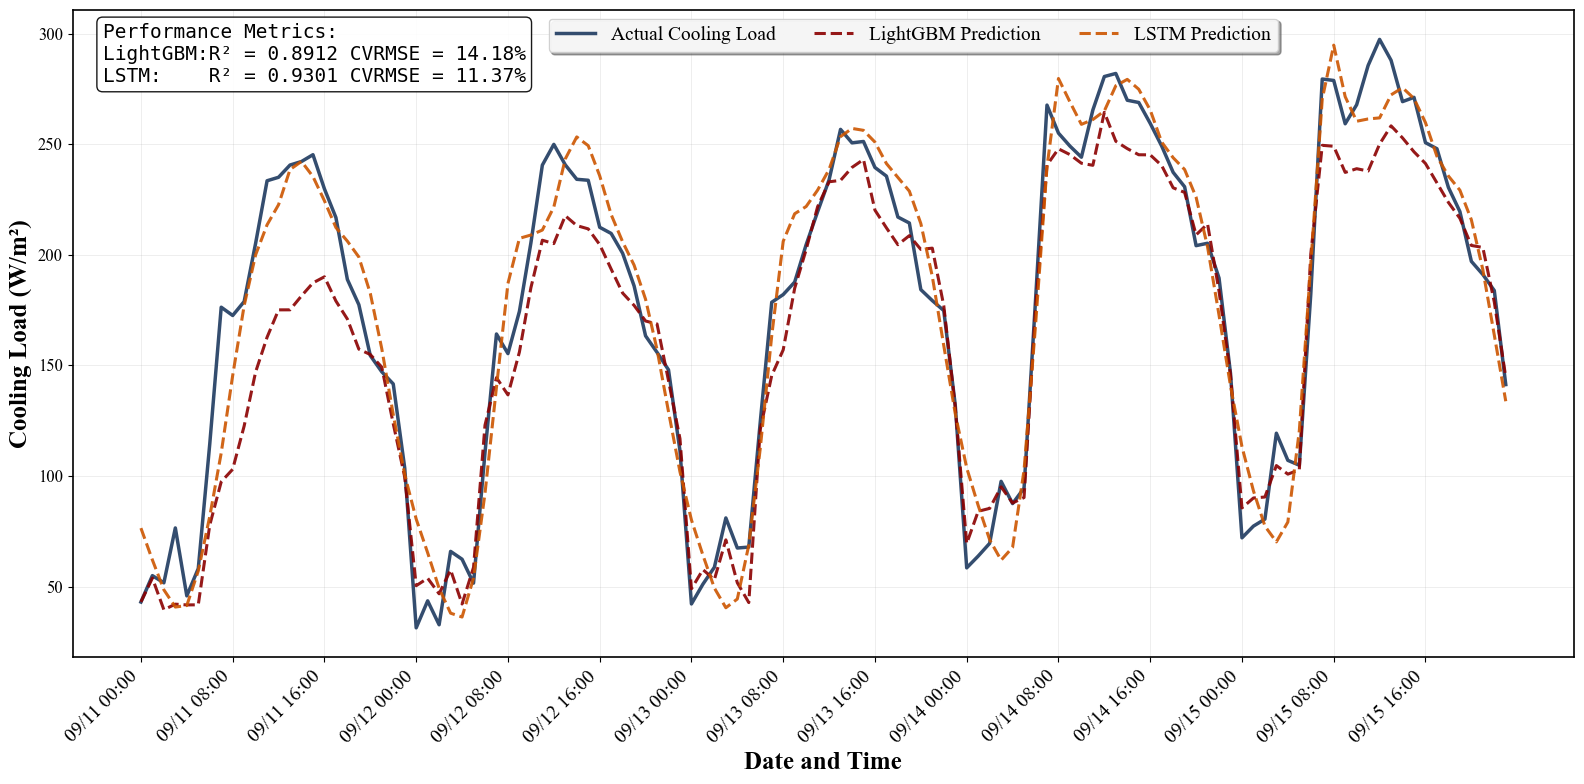


模型性能详细对比分析

LightGBM相对于LSTM的改进:
RMSE改进: -24.70%
CVRMSE改进: -24.70%
R²改进: -4.17%
MAE改进: -16.30%

基于RMSE指标，更好的模型是: LSTM

详细对比数据已保存至: E:/bishe/BULL_Model_Comparison_Data.csv

测试集信息:
时间范围: 2017-09-11 00:00 到 2017-09-15 23:00
总数据点: 120
天数: 5 天
包含的星期: Friday, Monday, Thursday, Tuesday, Wednesday


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import math

# ==================== 设置中文字体和样式 ====================
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.2

# ==================== 加载两个模型的预测数据 ====================
# 加载LightGBM预测数据
lgb_data = pd.read_csv("E:/bishe/BULL_lightgbm_predictions.csv", parse_dates=['timestamp'])
# 加载LSTM预测数据
lstm_data = pd.read_csv("E:/bishe/Bull_LSTM_predictions.csv", parse_dates=['timestamp'])

# ==================== 确保时间戳对齐 ====================
# 找到两个数据集共有的时间戳
common_timestamps = set(lgb_data['timestamp']).intersection(set(lstm_data['timestamp']))
lgb_common = lgb_data[lgb_data['timestamp'].isin(common_timestamps)].sort_values('timestamp')
lstm_common = lstm_data[lstm_data['timestamp'].isin(common_timestamps)].sort_values('timestamp')

# 重置索引
lgb_common = lgb_common.reset_index(drop=True)
lstm_common = lstm_common.reset_index(drop=True)

print(f"LightGBM数据点: {len(lgb_common)}")
print(f"LSTM数据点: {len(lstm_common)}")
print(f"共同数据点: {len(common_timestamps)}")

# ==================== 计算两个模型的性能指标 ====================
# LightGBM指标
lgb_actual = lgb_common['actual'].values
lgb_predicted = lgb_common['predicted'].values

lgb_rmse = math.sqrt(mean_squared_error(lgb_actual, lgb_predicted))
lgb_cvrmse = (lgb_rmse / np.mean(lgb_actual)) * 100
lgb_r2 = r2_score(lgb_actual, lgb_predicted)
lgb_mae = mean_absolute_error(lgb_actual, lgb_predicted)

# LSTM指标
lstm_actual = lstm_common['actual'].values
lstm_predicted = lstm_common['predicted'].values

lstm_rmse = math.sqrt(mean_squared_error(lstm_actual, lstm_predicted))
lstm_cvrmse = (lstm_rmse / np.mean(lstm_actual)) * 100
lstm_r2 = r2_score(lstm_actual, lstm_predicted)
lstm_mae = mean_absolute_error(lstm_actual, lstm_predicted)

print("\n模型性能对比:")
print(f"LightGBM - RMSE: {lgb_rmse:.2f}, CVRMSE: {lgb_cvrmse:.2f}%, R²: {lgb_r2:.4f}, MAE: {lgb_mae:.2f}")
print(f"LSTM     - RMSE: {lstm_rmse:.2f}, CVRMSE: {lstm_cvrmse:.2f}%, R²: {lstm_r2:.4f}, MAE: {lstm_mae:.2f}")

# ==================== 创建组合对比图 ====================
fig, ax = plt.subplots(figsize=(16, 8))
fig.subplots_adjust(top=0.90)

# 获取时间戳
timestamps = lgb_common['timestamp']

# 绘制实际负荷线（深蓝色实线）
line_actual, = ax.plot(timestamps, lgb_actual, 
                      label='Actual Cooling Load', 
                      color='#1E3A5F', linewidth=2.5, alpha=0.9)

# 绘制LightGBM预测线（深红色虚线）
line_lgb, = ax.plot(timestamps, lgb_predicted, 
                   label='LightGBM Prediction', 
                   color='#8B0000', linewidth=2.2, alpha=0.9, linestyle='--')

# 绘制LSTM预测线（深橙色虚线）
line_lstm, = ax.plot(timestamps, lstm_predicted, 
                    label='LSTM Prediction', 
                    color='#CC5500', linewidth=2.2, alpha=0.9, linestyle='--')

# 格式化日期标签
date_labels = timestamps.dt.strftime('%m/%d %H:%M')
n = len(timestamps)
step = max(1, n // 15)

# 设置x轴刻度和标签
ax.set_xticks(timestamps[::step])
ax.set_xticklabels(date_labels[::step], rotation=45, ha='right', fontsize=14)
ax.set_xlabel('Date and Time', fontsize=18, fontweight='bold')

# 添加网格线
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# 设置y轴标签 - 修改这里：将m2改为m²
ax.set_ylabel('Cooling Load (W/m²)', fontsize=18, fontweight='bold')

# 添加图例 - 横排排列在图的最上方
ax.legend(loc='lower center', bbox_to_anchor=(0.56, 0.92), 
          frameon=True, fancybox=True, shadow=True, 
          framealpha=0.9, fontsize=14, ncol=3)

# ==================== 在左上方添加性能指标文本框 - 三行布局，减少行间距 ====================
metrics_text = (
    f'Performance Metrics:\n'
    f'LightGBM:R² = {lgb_r2:.4f} CVRMSE = {lgb_cvrmse:.2f}%\n'
    f'LSTM:    R² = {lstm_r2:.4f} CVRMSE = {lstm_cvrmse:.2f}%'
)

# 创建文本框
bbox_props = dict(boxstyle='round', facecolor='white', alpha=0.9, 
                  edgecolor='black', linewidth=1)

# 使用linespacing参数减少行间距
ax.text(0.02, 0.98, metrics_text, transform=ax.transAxes, 
        verticalalignment='top', 
        bbox=bbox_props, 
        fontsize=14,
        fontfamily='monospace',
        linespacing=1.2)  # 减少行间距，默认是1.5


# 调整布局
plt.tight_layout()

# 保存为高质量图像
plt.savefig("E:/bishe/BULL_Model_Comparison.svg", format='svg', dpi=300, bbox_inches='tight')
plt.savefig("E:/bishe/BULL_Model_Comparison.png", dpi=300, bbox_inches='tight')

print("\n对比图已保存至:")
print(" - E:/bishe/BULL_Model_Comparison.svg")
print(" - E:/bishe/BULL_Model_Comparison.png")

plt.show()

# ==================== 输出详细对比分析 ====================
print("\n" + "="*60)
print("模型性能详细对比分析")
print("="*60)

# 计算相对改进
rmse_improvement = ((lstm_rmse - lgb_rmse) / lstm_rmse) * 100
cvrmse_improvement = ((lstm_cvrmse - lgb_cvrmse) / lstm_cvrmse) * 100
r2_improvement = ((lgb_r2 - lstm_r2) / lstm_r2) * 100
mae_improvement = ((lstm_mae - lgb_mae) / lstm_mae) * 100

print(f"\nLightGBM相对于LSTM的改进:")
print(f"RMSE改进: {rmse_improvement:+.2f}%")
print(f"CVRMSE改进: {cvrmse_improvement:+.2f}%") 
print(f"R²改进: {r2_improvement:+.2f}%")
print(f"MAE改进: {mae_improvement:+.2f}%")

# 确定哪个模型更好
better_model = "LightGBM" if lgb_rmse < lstm_rmse else "LSTM"
print(f"\n基于RMSE指标，更好的模型是: {better_model}")

# 保存对比数据
comparison_data = pd.DataFrame({
    'timestamp': timestamps,
    'actual': lgb_actual,
    'lightgbm_predicted': lgb_predicted,
    'lstm_predicted': lstm_predicted,
    'lightgbm_error': lgb_predicted - lgb_actual,
    'lstm_error': lstm_predicted - lstm_actual
})

comparison_data.to_csv("E:/bishe/BULL_Model_Comparison_Data.csv", index=False)
print(f"\n详细对比数据已保存至: E:/bishe/BULL_Model_Comparison_Data.csv")

# 输出测试集信息
print(f"\n测试集信息:")
print(f"时间范围: {timestamps.min().strftime('%Y-%m-%d %H:%M')} 到 {timestamps.max().strftime('%Y-%m-%d %H:%M')}")
print(f"总数据点: {len(timestamps)}")
print(f"天数: {timestamps.dt.date.nunique()} 天")
print(f"包含的星期: {', '.join(sorted(timestamps.dt.strftime('%A').unique()))}")

普通LightGBM数据点: 120
迁移学习LightGBM数据点: 120
共同数据点: 120

模型性能对比:
普通LightGBM - RMSE: 24.94, CVRMSE: 14.18%, R²: 0.8912, MAE: 18.26
迁移学习LightGBM - RMSE: 18.23, CVRMSE: 10.36%, R²: 0.9419, MAE: 14.86

对比图已保存至:
 - E:/bishe/LightGBM_Transfer_Comparison.svg
 - E:/bishe/LightGBM_Transfer_Comparison.png


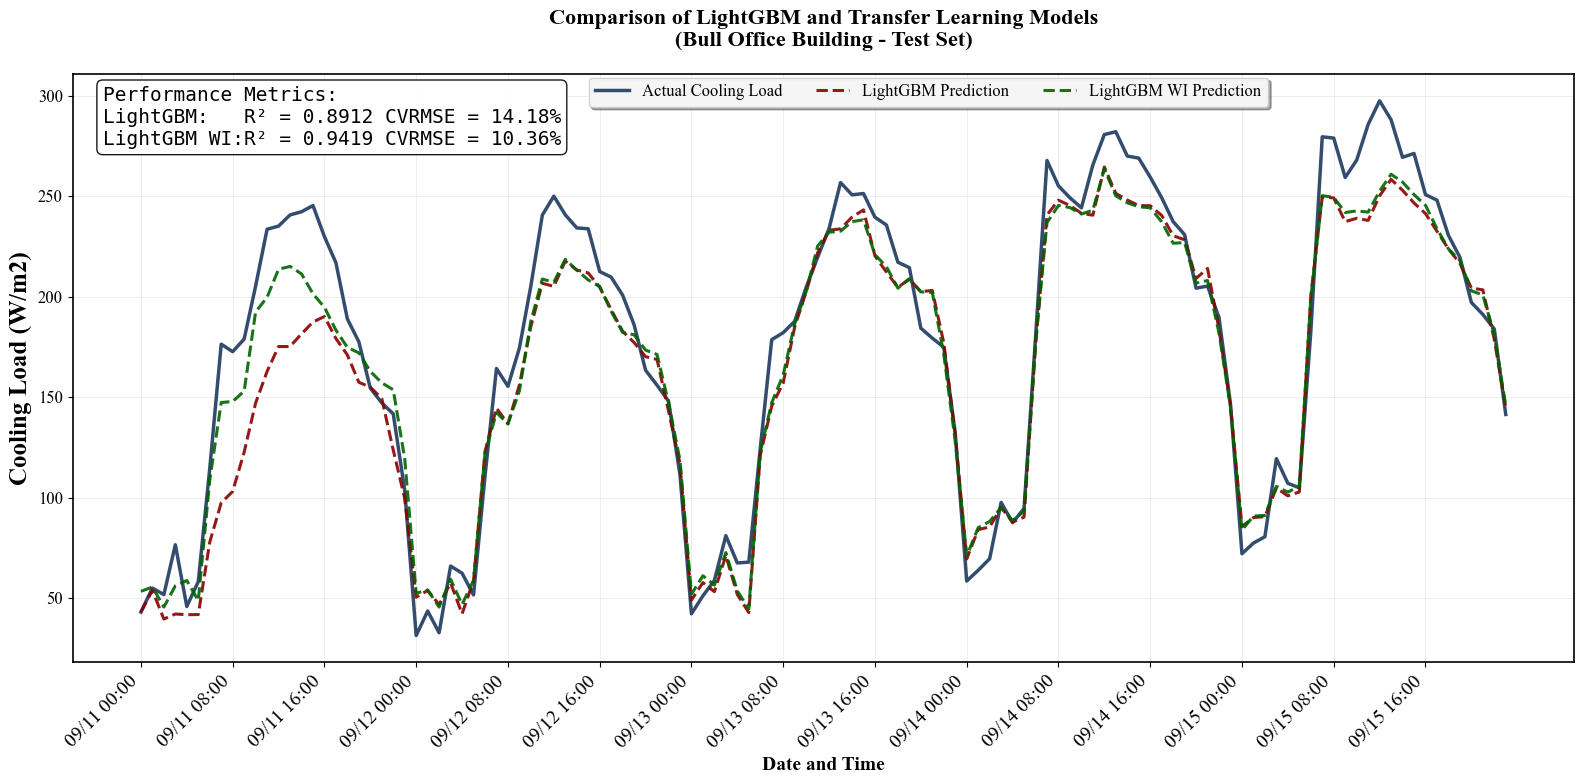


模型性能详细对比分析

迁移学习相对于普通LightGBM的改进:
RMSE改进: +26.93%
CVRMSE改进: +26.93%
R²改进: +5.69%
MAE改进: +18.61%

基于RMSE指标，更好的模型是: 迁移学习LightGBM

详细对比数据已保存至: E:/bishe/LightGBM_Transfer_Comparison_Data.csv

测试集信息:
时间范围: 2017-09-11 00:00 到 2017-09-15 23:00
总数据点: 120
天数: 5 天
包含的星期: Friday, Monday, Thursday, Tuesday, Wednesday


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import math

# ==================== 设置中文字体和样式 ====================
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.2

# ==================== 加载两个模型的预测数据 ====================
# 加载普通LightGBM预测数据
lgb_data = pd.read_csv("E:/bishe/BULL_lightgbm_predictions.csv", parse_dates=['timestamp'])
# 加载迁移学习LightGBM预测数据
transfer_data = pd.read_csv("E:/bishe/transfer_learning_predictions.csv", parse_dates=['timestamp'])

# ==================== 确保时间戳对齐 ====================
# 找到两个数据集共有的时间戳
common_timestamps = set(lgb_data['timestamp']).intersection(set(transfer_data['timestamp']))
lgb_common = lgb_data[lgb_data['timestamp'].isin(common_timestamps)].sort_values('timestamp')
transfer_common = transfer_data[transfer_data['timestamp'].isin(common_timestamps)].sort_values('timestamp')

# 重置索引
lgb_common = lgb_common.reset_index(drop=True)
transfer_common = transfer_common.reset_index(drop=True)

print(f"普通LightGBM数据点: {len(lgb_common)}")
print(f"迁移学习LightGBM数据点: {len(transfer_common)}")
print(f"共同数据点: {len(common_timestamps)}")

# ==================== 计算两个模型的性能指标 ====================
# 普通LightGBM指标
lgb_actual = lgb_common['actual'].values
lgb_predicted = lgb_common['predicted'].values

lgb_rmse = math.sqrt(mean_squared_error(lgb_actual, lgb_predicted))
lgb_cvrmse = (lgb_rmse / np.mean(lgb_actual)) * 100
lgb_r2 = r2_score(lgb_actual, lgb_predicted)
lgb_mae = mean_absolute_error(lgb_actual, lgb_predicted)

# 迁移学习LightGBM指标
transfer_actual = transfer_common['actual'].values
transfer_predicted = transfer_common['predicted'].values

transfer_rmse = math.sqrt(mean_squared_error(transfer_actual, transfer_predicted))
transfer_cvrmse = (transfer_rmse / np.mean(transfer_actual)) * 100
transfer_r2 = r2_score(transfer_actual, transfer_predicted)
transfer_mae = mean_absolute_error(transfer_actual, transfer_predicted)

print("\n模型性能对比:")
print(f"普通LightGBM - RMSE: {lgb_rmse:.2f}, CVRMSE: {lgb_cvrmse:.2f}%, R²: {lgb_r2:.4f}, MAE: {lgb_mae:.2f}")
print(f"迁移学习LightGBM - RMSE: {transfer_rmse:.2f}, CVRMSE: {transfer_cvrmse:.2f}%, R²: {transfer_r2:.4f}, MAE: {transfer_mae:.2f}")

# ==================== 创建组合对比图 ====================
fig, ax = plt.subplots(figsize=(16, 8))
fig.subplots_adjust(top=0.90)

# 获取时间戳
timestamps = lgb_common['timestamp']

# 绘制实际负荷线（深蓝色实线）
line_actual, = ax.plot(timestamps, lgb_actual, 
                      label='Actual Cooling Load', 
                      color='#1E3A5F', linewidth=2.5, alpha=0.9)

# 绘制普通LightGBM预测线（深红色虚线）
line_lgb, = ax.plot(timestamps, lgb_predicted, 
                   label='LightGBM Prediction', 
                   color='#8B0000', linewidth=2.2, alpha=0.9, linestyle='--')

# 绘制迁移学习LightGBM预测线（深绿色虚线）
line_transfer, = ax.plot(timestamps, transfer_predicted, 
                        label='LightGBM WI Prediction', 
                        color='#006400', linewidth=2.2, alpha=0.9, linestyle='--')  # 改为深绿色

# 格式化日期标签
date_labels = timestamps.dt.strftime('%m/%d %H:%M')
n = len(timestamps)
step = max(1, n // 15)

# 设置x轴刻度和标签
ax.set_xticks(timestamps[::step])
ax.set_xticklabels(date_labels[::step], rotation=45, ha='right', fontsize=14)
ax.set_xlabel('Date and Time', fontsize=14, fontweight='bold')

# 添加网格线
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# 设置y轴标签
ax.set_ylabel('Cooling Load (W/m2)', fontsize=18, fontweight='bold')

# 添加图例 - 横排排列在图的最上方
ax.legend(loc='lower center', bbox_to_anchor=(0.57, 0.93), 
          frameon=True, fancybox=True, shadow=True, 
          framealpha=0.9, fontsize=12, ncol=3)

# ==================== 在左上方添加性能指标文本框 - 三行布局，减少行间距 ====================
metrics_text = (
    f'Performance Metrics:\n'
    f'LightGBM:   R² = {lgb_r2:.4f} CVRMSE = {lgb_cvrmse:.2f}%\n'
    f'LightGBM WI:R² = {transfer_r2:.4f} CVRMSE = {transfer_cvrmse:.2f}%'
)

# 创建文本框
bbox_props = dict(boxstyle='round', facecolor='white', alpha=0.9, 
                  edgecolor='black', linewidth=1)

# 使用linespacing参数减少行间距
ax.text(0.02, 0.98, metrics_text, transform=ax.transAxes, 
        verticalalignment='top', 
        bbox=bbox_props, 
        fontsize=14,
        fontfamily='monospace',
        linespacing=1.2)  # 减少行间距，默认是1.5

# 设置标题（英文）
ax.set_title('Comparison of LightGBM and Transfer Learning Models\n(Bull Office Building - Test Set)', 
             fontsize=16, fontweight='bold', pad=20)

# 调整布局
plt.tight_layout()

# 保存为高质量图像
plt.savefig("E:/bishe/LightGBM_Transfer_Comparison.svg", format='svg', dpi=300, bbox_inches='tight')
plt.savefig("E:/bishe/LightGBM_Transfer_Comparison.png", dpi=300, bbox_inches='tight')

print("\n对比图已保存至:")
print(" - E:/bishe/LightGBM_Transfer_Comparison.svg")
print(" - E:/bishe/LightGBM_Transfer_Comparison.png")

plt.show()

# ==================== 输出详细对比分析 ====================
print("\n" + "="*60)
print("模型性能详细对比分析")
print("="*60)

# 计算相对改进
rmse_improvement = ((lgb_rmse - transfer_rmse) / lgb_rmse) * 100
cvrmse_improvement = ((lgb_cvrmse - transfer_cvrmse) / lgb_cvrmse) * 100
r2_improvement = ((transfer_r2 - lgb_r2) / lgb_r2) * 100
mae_improvement = ((lgb_mae - transfer_mae) / lgb_mae) * 100

print(f"\n迁移学习相对于普通LightGBM的改进:")
print(f"RMSE改进: {rmse_improvement:+.2f}%")
print(f"CVRMSE改进: {cvrmse_improvement:+.2f}%") 
print(f"R²改进: {r2_improvement:+.2f}%")
print(f"MAE改进: {mae_improvement:+.2f}%")

# 确定哪个模型更好
better_model = "迁移学习LightGBM" if transfer_rmse < lgb_rmse else "普通LightGBM"
print(f"\n基于RMSE指标，更好的模型是: {better_model}")

# 保存对比数据
comparison_data = pd.DataFrame({
    'timestamp': timestamps,
    'actual': lgb_actual,
    'lightgbm_predicted': lgb_predicted,
    'transfer_learning_predicted': transfer_predicted,
    'lightgbm_error': lgb_predicted - lgb_actual,
    'transfer_learning_error': transfer_predicted - transfer_actual
})

comparison_data.to_csv("E:/bishe/LightGBM_Transfer_Comparison_Data.csv", index=False)
print(f"\n详细对比数据已保存至: E:/bishe/LightGBM_Transfer_Comparison_Data.csv")

# 输出测试集信息
print(f"\n测试集信息:")
print(f"时间范围: {timestamps.min().strftime('%Y-%m-%d %H:%M')} 到 {timestamps.max().strftime('%Y-%m-%d %H:%M')}")
print(f"总数据点: {len(timestamps)}")
print(f"天数: {timestamps.dt.date.nunique()} 天")
print(f"包含的星期: {', '.join(sorted(timestamps.dt.strftime('%A').unique()))}")

普通LSTM数据点: 120
LSTM微调数据点: 120
LSTM特征提取数据点: 120
共同数据点: 120

模型性能对比:
普通LSTM - CVRMSE: 11.37%, R²: 0.9301
LSTM微调 - CVRMSE: 11.16%, R²: 0.9325
LSTM特征提取 - CVRMSE: 24.23%, R²: 0.6823

对比图已保存至:
 - E:/bishe/LSTM_Models_Comparison.svg
 - E:/bishe/LSTM_Models_Comparison.png


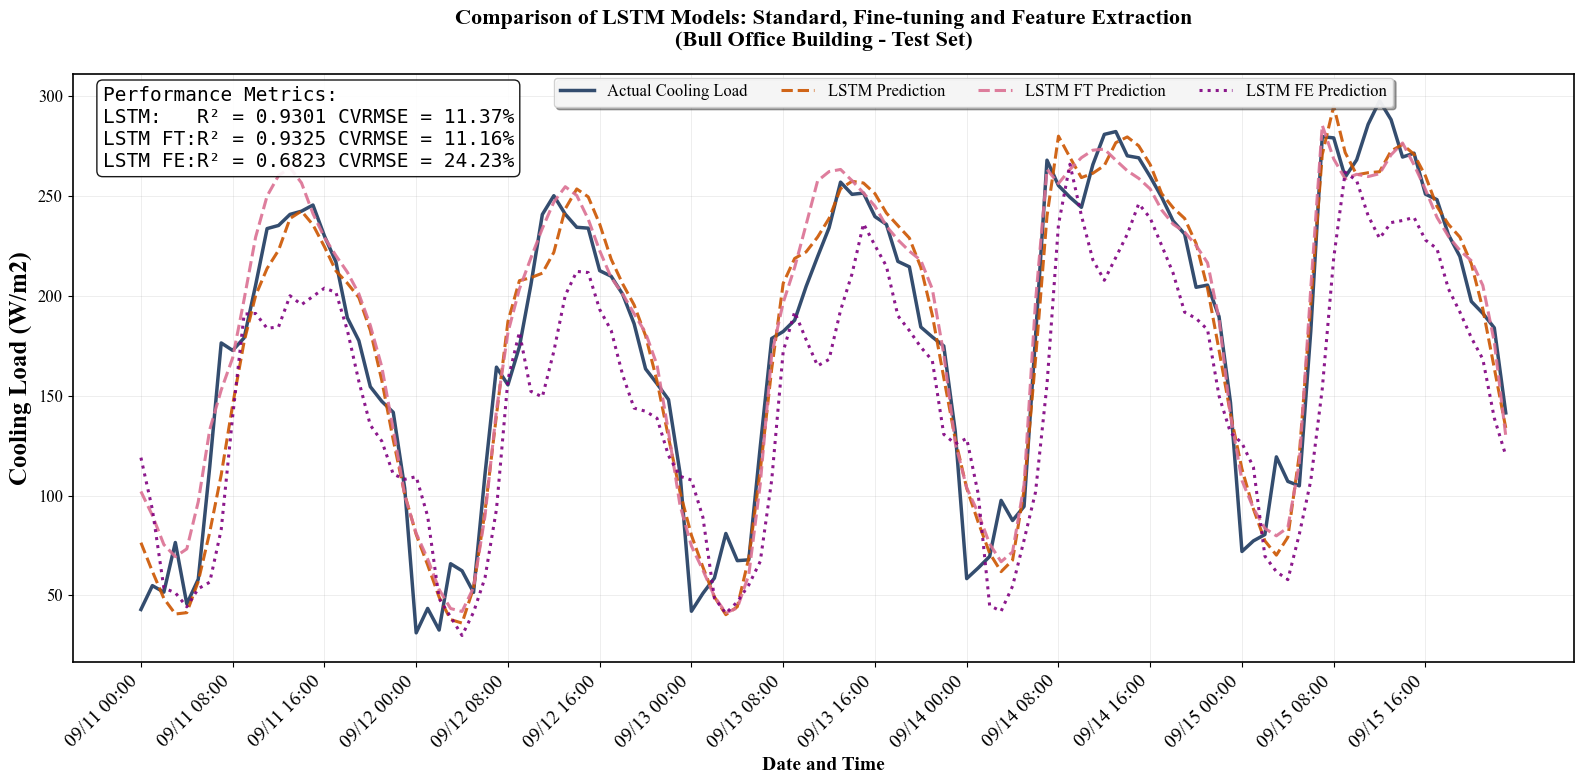


LSTM模型性能详细对比分析

相对于普通LSTM的改进:
LSTM微调:
  CVRMSE改进: +1.79%
  R²改进: +0.27%

LSTM特征提取:
  CVRMSE改进: -113.14%
  R²改进: -26.64%

基于RMSE指标，最好的模型是: LSTM微调

详细对比数据已保存至: E:/bishe/LSTM_Models_Comparison_Data.csv

测试集信息:
时间范围: 2017-09-11 00:00 到 2017-09-15 23:00
总数据点: 120
天数: 5 天
包含的星期: Friday, Monday, Thursday, Tuesday, Wednesday


In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import math

# ==================== 设置中文字体和样式 ====================
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.2

# ==================== 加载三个LSTM模型的预测数据 ====================
# 加载普通LSTM预测数据
lstm_data = pd.read_csv("E:/bishe/Bull_LSTM_predictions.csv", parse_dates=['timestamp'])
# 加载LSTM微调预测数据
lstm_finetune_data = pd.read_csv("E:/bishe/BULL_lstm_transfer_learning_predictions.csv", parse_dates=['timestamp'])
# 加载LSTM特征提取预测数据
lstm_feature_data = pd.read_csv("E:/bishe/BULL_lstm_feature_extract_predictions.csv", parse_dates=['timestamp'])

# ==================== 确保时间戳对齐 ====================
# 找到三个数据集共有的时间戳
common_timestamps = set(lstm_data['timestamp']).intersection(
    set(lstm_finetune_data['timestamp']), 
    set(lstm_feature_data['timestamp'])
)

lstm_common = lstm_data[lstm_data['timestamp'].isin(common_timestamps)].sort_values('timestamp')
lstm_finetune_common = lstm_finetune_data[lstm_finetune_data['timestamp'].isin(common_timestamps)].sort_values('timestamp')
lstm_feature_common = lstm_feature_data[lstm_feature_data['timestamp'].isin(common_timestamps)].sort_values('timestamp')

# 重置索引
lstm_common = lstm_common.reset_index(drop=True)
lstm_finetune_common = lstm_finetune_common.reset_index(drop=True)
lstm_feature_common = lstm_feature_common.reset_index(drop=True)

print(f"普通LSTM数据点: {len(lstm_common)}")
print(f"LSTM微调数据点: {len(lstm_finetune_common)}")
print(f"LSTM特征提取数据点: {len(lstm_feature_common)}")
print(f"共同数据点: {len(common_timestamps)}")

# ==================== 计算三个模型的性能指标 ====================
# 普通LSTM指标
lstm_actual = lstm_common['actual'].values
lstm_predicted = lstm_common['predicted'].values

lstm_rmse = math.sqrt(mean_squared_error(lstm_actual, lstm_predicted))
lstm_cvrmse = (lstm_rmse / np.mean(lstm_actual)) * 100
lstm_r2 = r2_score(lstm_actual, lstm_predicted)

# LSTM微调指标
lstm_finetune_actual = lstm_finetune_common['actual'].values
lstm_finetune_predicted = lstm_finetune_common['predicted'].values

lstm_finetune_rmse = math.sqrt(mean_squared_error(lstm_finetune_actual, lstm_finetune_predicted))
lstm_finetune_cvrmse = (lstm_finetune_rmse / np.mean(lstm_finetune_actual)) * 100
lstm_finetune_r2 = r2_score(lstm_finetune_actual, lstm_finetune_predicted)

# LSTM特征提取指标
lstm_feature_actual = lstm_feature_common['actual'].values
lstm_feature_predicted = lstm_feature_common['predicted'].values

lstm_feature_rmse = math.sqrt(mean_squared_error(lstm_feature_actual, lstm_feature_predicted))
lstm_feature_cvrmse = (lstm_feature_rmse / np.mean(lstm_feature_actual)) * 100
lstm_feature_r2 = r2_score(lstm_feature_actual, lstm_feature_predicted)

print("\n模型性能对比:")
print(f"普通LSTM - CVRMSE: {lstm_cvrmse:.2f}%, R²: {lstm_r2:.4f}")
print(f"LSTM微调 - CVRMSE: {lstm_finetune_cvrmse:.2f}%, R²: {lstm_finetune_r2:.4f}")
print(f"LSTM特征提取 - CVRMSE: {lstm_feature_cvrmse:.2f}%, R²: {lstm_feature_r2:.4f}")

# ==================== 创建组合对比图 ====================
fig, ax = plt.subplots(figsize=(16, 8))
fig.subplots_adjust(top=0.90)

# 获取时间戳
timestamps = lstm_common['timestamp']

# 绘制实际负荷线（深蓝色实线）
line_actual, = ax.plot(timestamps, lstm_actual, 
                      label='Actual Cooling Load', 
                      color='#1E3A5F', linewidth=2.5, alpha=0.9)

# 绘制普通LSTM预测线（#CC5500色虚线）
line_lstm, = ax.plot(timestamps, lstm_predicted, 
                    label='LSTM Prediction', 
                    color='#CC5500', linewidth=2.2, alpha=0.9, linestyle='--')

# 绘制LSTM微调预测线（浅粉色虚线）
line_finetune, = ax.plot(timestamps, lstm_finetune_predicted, 
                        label='LSTM FT Prediction', 
                        color='#DB7093', linewidth=2.2, alpha=0.9, linestyle='--')  # 浅粉色

# 绘制LSTM特征提取预测线（正常紫色虚线）
line_feature, = ax.plot(timestamps, lstm_feature_predicted, 
                       label='LSTM FE Prediction', 
                       color='#800080', linewidth=2.2, alpha=0.9, linestyle=':')  # 正常紫色

# 格式化日期标签
date_labels = timestamps.dt.strftime('%m/%d %H:%M')
n = len(timestamps)
step = max(1, n // 15)

# 设置x轴刻度和标签
ax.set_xticks(timestamps[::step])
ax.set_xticklabels(date_labels[::step], rotation=45, ha='right', fontsize=14)
ax.set_xlabel('Date and Time', fontsize=14, fontweight='bold')

# 添加网格线
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# 设置y轴标签
ax.set_ylabel('Cooling Load (W/m2)', fontsize=18, fontweight='bold')

# 添加图例 - 横排排列在图的最上方
ax.legend(loc='lower center', bbox_to_anchor=(0.6, 0.93), 
          frameon=True, fancybox=True, shadow=True, 
          framealpha=0.9, fontsize=12, ncol=4)  # 减小字体以适应4列

# ==================== 在左上方添加性能指标文本框 - 四行布局，减少行间距 ====================
metrics_text = (
    f'Performance Metrics:\n'
    f'LSTM:   R² = {lstm_r2:.4f} CVRMSE = {lstm_cvrmse:.2f}%\n'
    f'LSTM FT:R² = {lstm_finetune_r2:.4f} CVRMSE = {lstm_finetune_cvrmse:.2f}%\n'
    f'LSTM FE:R² = {lstm_feature_r2:.4f} CVRMSE = {lstm_feature_cvrmse:.2f}%'
)

# 创建文本框
bbox_props = dict(boxstyle='round', facecolor='white', alpha=0.9, 
                  edgecolor='black', linewidth=1)

# 使用linespacing参数减少行间距
ax.text(0.02, 0.98, metrics_text, transform=ax.transAxes, 
        verticalalignment='top', 
        bbox=bbox_props, 
        fontsize=14,  # 减小字体以适应更多行
        fontfamily='monospace',
        linespacing=1.2)  # 进一步减少行间距

# 设置标题（英文）
ax.set_title('Comparison of LSTM Models: Standard, Fine-tuning and Feature Extraction\n(Bull Office Building - Test Set)', 
             fontsize=16, fontweight='bold', pad=20)

# 调整布局
plt.tight_layout()

# 保存为高质量图像
plt.savefig("E:/bishe/LSTM_Models_Comparison.svg", format='svg', dpi=300, bbox_inches='tight')
plt.savefig("E:/bishe/LSTM_Models_Comparison.png", dpi=300, bbox_inches='tight')

print("\n对比图已保存至:")
print(" - E:/bishe/LSTM_Models_Comparison.svg")
print(" - E:/bishe/LSTM_Models_Comparison.png")

plt.show()

# ==================== 输出详细对比分析 ====================
print("\n" + "="*60)
print("LSTM模型性能详细对比分析")
print("="*60)

# 计算相对改进（以普通LSTM为基准）
finetune_cvrmse_improvement = ((lstm_cvrmse - lstm_finetune_cvrmse) / lstm_cvrmse) * 100
finetune_r2_improvement = ((lstm_finetune_r2 - lstm_r2) / lstm_r2) * 100

feature_cvrmse_improvement = ((lstm_cvrmse - lstm_feature_cvrmse) / lstm_cvrmse) * 100
feature_r2_improvement = ((lstm_feature_r2 - lstm_r2) / lstm_r2) * 100

print(f"\n相对于普通LSTM的改进:")
print(f"LSTM微调:")
print(f"  CVRMSE改进: {finetune_cvrmse_improvement:+.2f}%") 
print(f"  R²改进: {finetune_r2_improvement:+.2f}%")

print(f"\nLSTM特征提取:")
print(f"  CVRMSE改进: {feature_cvrmse_improvement:+.2f}%") 
print(f"  R²改进: {feature_r2_improvement:+.2f}%")

# 确定哪个模型最好
models_performance = {
    '普通LSTM': lstm_rmse,
    'LSTM微调': lstm_finetune_rmse,
    'LSTM特征提取': lstm_feature_rmse
}
best_model = min(models_performance, key=models_performance.get)
print(f"\n基于RMSE指标，最好的模型是: {best_model}")

# 保存对比数据
comparison_data = pd.DataFrame({
    'timestamp': timestamps,
    'actual': lstm_actual,
    'lstm_predicted': lstm_predicted,
    'lstm_finetune_predicted': lstm_finetune_predicted,
    'lstm_feature_predicted': lstm_feature_predicted
})

comparison_data.to_csv("E:/bishe/LSTM_Models_Comparison_Data.csv", index=False)
print(f"\n详细对比数据已保存至: E:/bishe/LSTM_Models_Comparison_Data.csv")

# 输出测试集信息
print(f"\n测试集信息:")
print(f"时间范围: {timestamps.min().strftime('%Y-%m-%d %H:%M')} 到 {timestamps.max().strftime('%Y-%m-%d %H:%M')}")
print(f"总数据点: {len(timestamps)}")
print(f"天数: {timestamps.dt.date.nunique()} 天")
print(f"包含的星期: {', '.join(sorted(timestamps.dt.strftime('%A').unique()))}")

LSTM微调（3源建筑）数据点: 120
LSTM全源域微调（6源建筑）数据点: 120
共同数据点: 120

模型性能对比:
LSTM微调（3源建筑） - CVRMSE: 11.16%, R²: 0.9325
LSTM全源域微调（6源建筑） - CVRMSE: 13.79%, R²: 0.8971

对比图已保存至:
 - E:/bishe/LSTM_Transfer_Learning_Comparison.svg
 - E:/bishe/LSTM_Transfer_Learning_Comparison.png


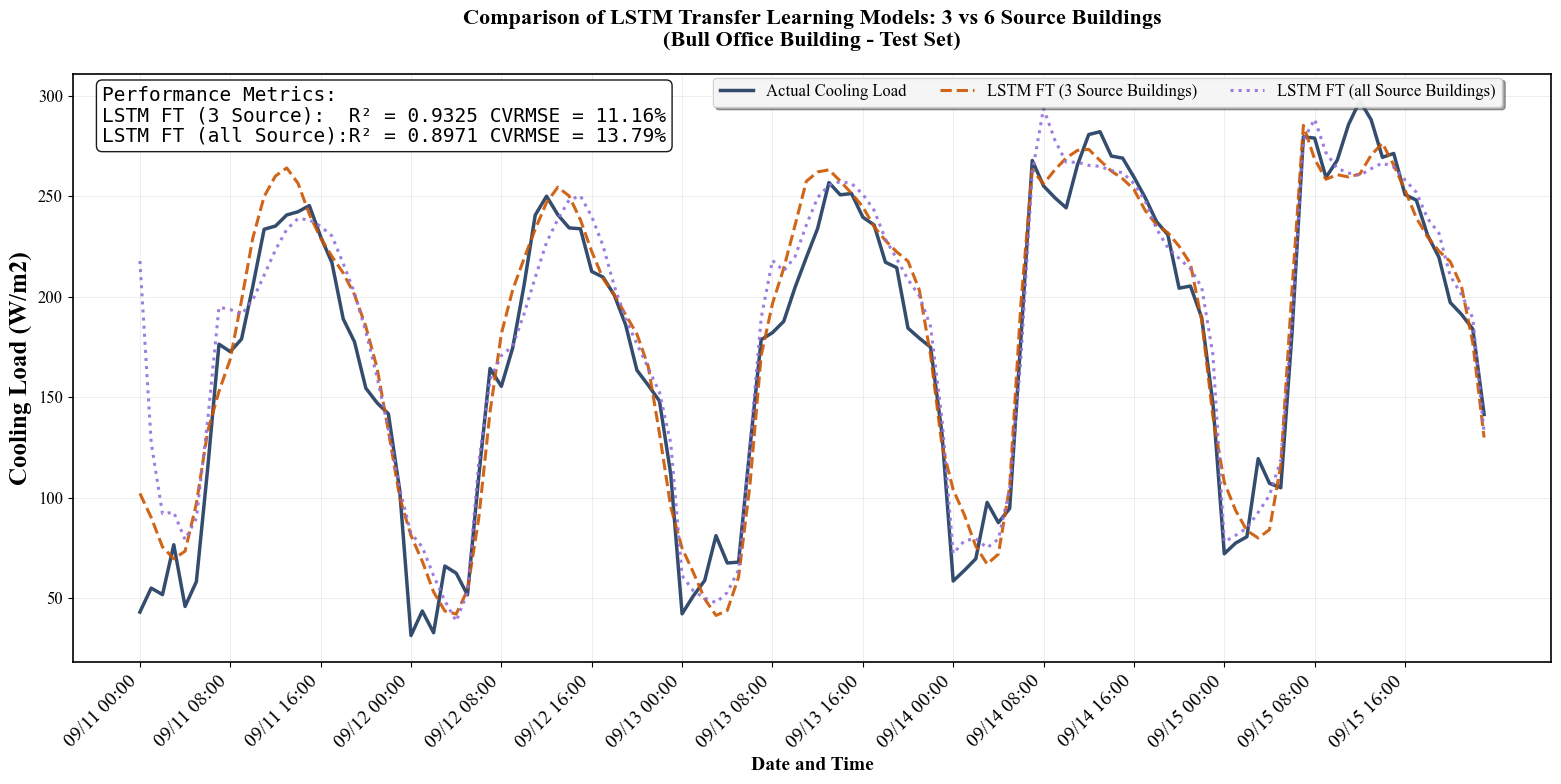


LSTM迁移学习模型性能详细对比分析

相对于3源建筑LSTM微调的改进:
6源建筑LSTM微调:
  CVRMSE改进: -23.52%
  R²改进: -3.80%

基于RMSE指标，最好的模型是: LSTM微调（3源建筑）

详细对比数据已保存至: E:/bishe/LSTM_Transfer_Learning_Comparison_Data.csv

测试集信息:
时间范围: 2017-09-11 00:00 到 2017-09-15 23:00
总数据点: 120
天数: 5 天
包含的星期: Friday, Monday, Thursday, Tuesday, Wednesday


In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import math

# ==================== 设置中文字体和样式 ====================
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.2

# ==================== 加载两个迁移学习模型的预测数据 ====================
# 加载LSTM微调预测数据（3个源建筑）
lstm_finetune_data = pd.read_csv("E:/bishe/BULL_lstm_transfer_learning_predictions.csv", parse_dates=['timestamp'])

# 加载LSTM全源域微调预测数据（6个源建筑）
lstm_full_source_data = pd.read_csv("E:/bishe/BULL_lstm_全源域_transfer_learning_predictions.csv", parse_dates=['timestamp'])

# ==================== 确保时间戳对齐 ====================
# 找到两个数据集共有的时间戳
common_timestamps = set(lstm_finetune_data['timestamp']).intersection(
    set(lstm_full_source_data['timestamp'])
)

lstm_finetune_common = lstm_finetune_data[lstm_finetune_data['timestamp'].isin(common_timestamps)].sort_values('timestamp')
lstm_full_source_common = lstm_full_source_data[lstm_full_source_data['timestamp'].isin(common_timestamps)].sort_values('timestamp')

# 重置索引
lstm_finetune_common = lstm_finetune_common.reset_index(drop=True)
lstm_full_source_common = lstm_full_source_common.reset_index(drop=True)

print(f"LSTM微调（3源建筑）数据点: {len(lstm_finetune_common)}")
print(f"LSTM全源域微调（6源建筑）数据点: {len(lstm_full_source_common)}")
print(f"共同数据点: {len(common_timestamps)}")

# ==================== 计算两个模型的性能指标 ====================
# LSTM微调指标（3源建筑）
lstm_finetune_actual = lstm_finetune_common['actual'].values
lstm_finetune_predicted = lstm_finetune_common['predicted'].values

lstm_finetune_rmse = math.sqrt(mean_squared_error(lstm_finetune_actual, lstm_finetune_predicted))
lstm_finetune_cvrmse = (lstm_finetune_rmse / np.mean(lstm_finetune_actual)) * 100
lstm_finetune_r2 = r2_score(lstm_finetune_actual, lstm_finetune_predicted)

# LSTM全源域微调指标（6源建筑）
lstm_full_source_actual = lstm_full_source_common['actual'].values
lstm_full_source_predicted = lstm_full_source_common['predicted'].values

lstm_full_source_rmse = math.sqrt(mean_squared_error(lstm_full_source_actual, lstm_full_source_predicted))
lstm_full_source_cvrmse = (lstm_full_source_rmse / np.mean(lstm_full_source_actual)) * 100
lstm_full_source_r2 = r2_score(lstm_full_source_actual, lstm_full_source_predicted)

print("\n模型性能对比:")
print(f"LSTM微调（3源建筑） - CVRMSE: {lstm_finetune_cvrmse:.2f}%, R²: {lstm_finetune_r2:.4f}")
print(f"LSTM全源域微调（6源建筑） - CVRMSE: {lstm_full_source_cvrmse:.2f}%, R²: {lstm_full_source_r2:.4f}")

# ==================== 创建组合对比图 ====================
fig, ax = plt.subplots(figsize=(16, 8))
fig.subplots_adjust(top=0.90)

# 获取时间戳
timestamps = lstm_finetune_common['timestamp']

# 绘制实际负荷线（深蓝色实线）
line_actual, = ax.plot(timestamps, lstm_finetune_actual, 
                      label='Actual Cooling Load', 
                      color='#1E3A5F', linewidth=2.5, alpha=0.9)

# 绘制LSTM微调预测线（橙色虚线）
line_finetune, = ax.plot(timestamps, lstm_finetune_predicted, 
                        label='LSTM FT (3 Source Buildings)', 
                        color='#CC5500', linewidth=2.2, alpha=0.9, linestyle='--')  # 珊瑚色

# 绘制LSTM全源域微调预测线（紫色虚线）
line_full_source, = ax.plot(timestamps, lstm_full_source_predicted, 
                           label='LSTM FT (all Source Buildings)', 
                           color='#9370DB', linewidth=2.2, alpha=0.9, linestyle=':')  # 中紫色

# 格式化日期标签
date_labels = timestamps.dt.strftime('%m/%d %H:%M')
n = len(timestamps)
step = max(1, n // 15)

# 设置x轴刻度和标签
ax.set_xticks(timestamps[::step])
ax.set_xticklabels(date_labels[::step], rotation=45, ha='right', fontsize=14)
ax.set_xlabel('Date and Time', fontsize=14, fontweight='bold')

# 添加网格线
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# 设置y轴标签
ax.set_ylabel('Cooling Load (W/m2)', fontsize=18, fontweight='bold')

# 添加图例 - 横排排列在图的最上方
ax.legend(loc='lower center', bbox_to_anchor=(0.7, 0.93), 
          frameon=True, fancybox=True, shadow=True, 
          framealpha=0.9, fontsize=12, ncol=3)

# ==================== 在左上方添加性能指标文本框 ====================
metrics_text = (
    f'Performance Metrics:\n'
    f'LSTM FT (3 Source):  R² = {lstm_finetune_r2:.4f} CVRMSE = {lstm_finetune_cvrmse:.2f}%\n'
    f'LSTM FT (all Source):R² = {lstm_full_source_r2:.4f} CVRMSE = {lstm_full_source_cvrmse:.2f}%'
)

# 创建文本框
bbox_props = dict(boxstyle='round', facecolor='white', alpha=0.9, 
                  edgecolor='black', linewidth=1)

# 使用linespacing参数减少行间距
ax.text(0.02, 0.98, metrics_text, transform=ax.transAxes, 
        verticalalignment='top', 
        bbox=bbox_props, 
        fontsize=14,
        fontfamily='monospace',
        linespacing=1.1)

# 设置标题（英文）
ax.set_title('Comparison of LSTM Transfer Learning Models: 3 vs 6 Source Buildings\n(Bull Office Building - Test Set)', 
             fontsize=16, fontweight='bold', pad=20)

# 调整布局
plt.tight_layout()

# 保存为高质量图像
plt.savefig("E:/bishe/LSTM_Transfer_Learning_Comparison.svg", format='svg', dpi=300, bbox_inches='tight')
plt.savefig("E:/bishe/LSTM_Transfer_Learning_Comparison.png", dpi=300, bbox_inches='tight')

print("\n对比图已保存至:")
print(" - E:/bishe/LSTM_Transfer_Learning_Comparison.svg")
print(" - E:/bishe/LSTM_Transfer_Learning_Comparison.png")

plt.show()

# ==================== 输出详细对比分析 ====================
print("\n" + "="*60)
print("LSTM迁移学习模型性能详细对比分析")
print("="*60)

# 计算相对改进（以3源建筑为基准）
full_source_cvrmse_improvement = ((lstm_finetune_cvrmse - lstm_full_source_cvrmse) / lstm_finetune_cvrmse) * 100
full_source_r2_improvement = ((lstm_full_source_r2 - lstm_finetune_r2) / lstm_finetune_r2) * 100

print(f"\n相对于3源建筑LSTM微调的改进:")
print(f"6源建筑LSTM微调:")
print(f"  CVRMSE改进: {full_source_cvrmse_improvement:+.2f}%") 
print(f"  R²改进: {full_source_r2_improvement:+.2f}%")

# 确定哪个模型最好
models_performance = {
    'LSTM微调（3源建筑）': lstm_finetune_rmse,
    'LSTM微调（6源建筑）': lstm_full_source_rmse
}
best_model = min(models_performance, key=models_performance.get)
print(f"\n基于RMSE指标，最好的模型是: {best_model}")

# 保存对比数据
comparison_data = pd.DataFrame({
    'timestamp': timestamps,
    'actual': lstm_finetune_actual,
    'lstm_finetune_3source_predicted': lstm_finetune_predicted,
    'lstm_finetune_6source_predicted': lstm_full_source_predicted
})

comparison_data.to_csv("E:/bishe/LSTM_Transfer_Learning_Comparison_Data.csv", index=False)
print(f"\n详细对比数据已保存至: E:/bishe/LSTM_Transfer_Learning_Comparison_Data.csv")

# 输出测试集信息
print(f"\n测试集信息:")
print(f"时间范围: {timestamps.min().strftime('%Y-%m-%d %H:%M')} 到 {timestamps.max().strftime('%Y-%m-%d %H:%M')}")
print(f"总数据点: {len(timestamps)}")
print(f"天数: {timestamps.dt.date.nunique()} 天")
print(f"包含的星期: {', '.join(sorted(timestamps.dt.strftime('%A').unique()))}")

LightGBM迁移学习（3源建筑）数据点: 120
LightGBM全源域迁移学习（6源建筑）数据点: 120
共同数据点: 120

LightGBM迁移学习模型性能对比:
LightGBM迁移学习（3源建筑） - CVRMSE: 10.36%, R²: 0.9419, MAE: 14.86
LightGBM全源域迁移学习（6源建筑） - CVRMSE: 10.84%, R²: 0.9364, MAE: 15.37

对比图已保存至:
 - E:/bishe/LightGBM_Transfer_Learning_Comparison.svg
 - E:/bishe/LightGBM_Transfer_Learning_Comparison.png


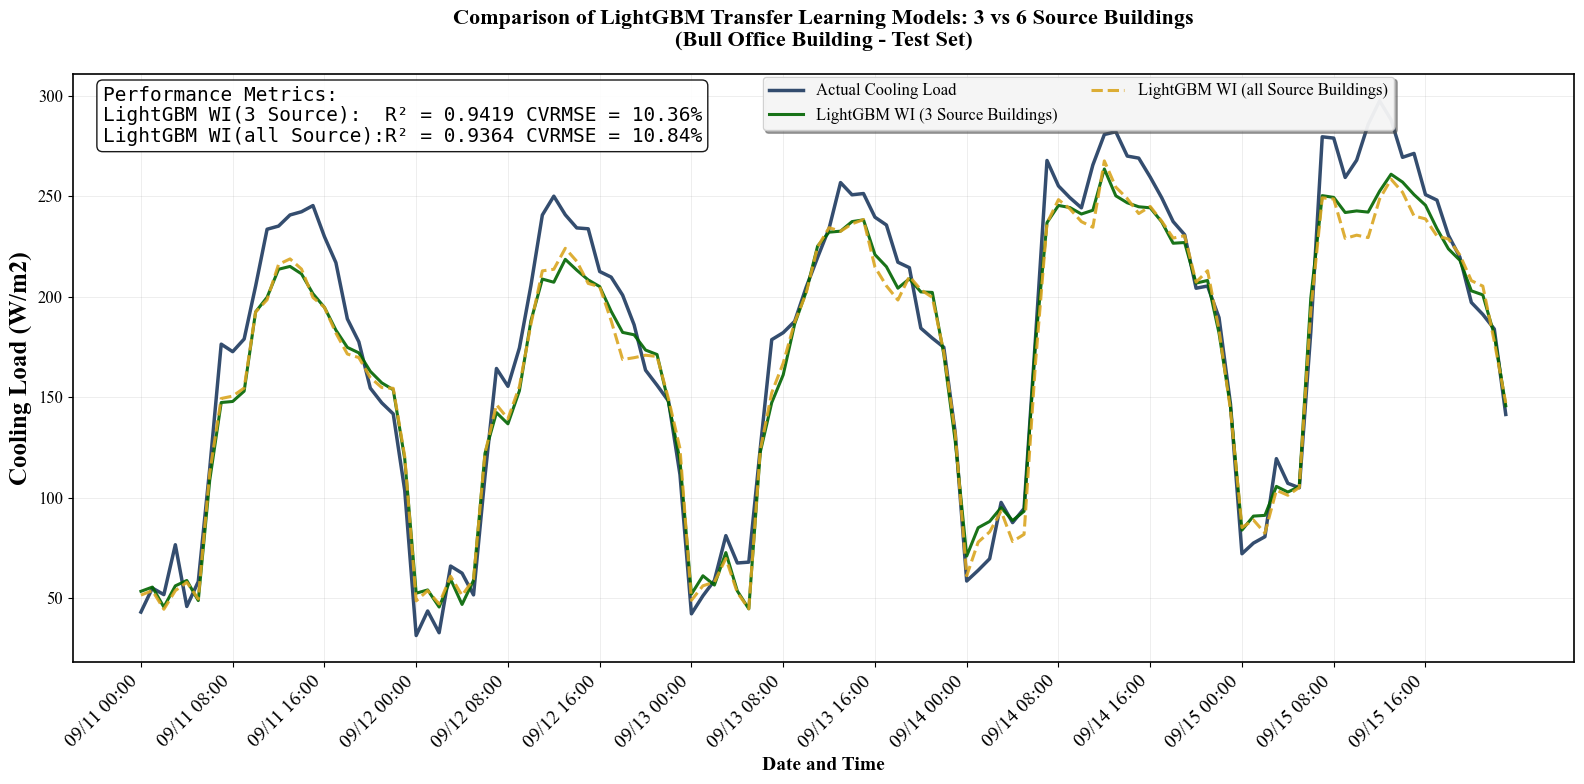

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import math

# ==================== 设置中文字体和样式 ====================
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.2

# ==================== 加载两个LightGBM迁移学习模型的预测数据 ====================
# 加载LightGBM迁移学习预测数据（3个源建筑）
lgb_finetune_data = pd.read_csv("E:/bishe/transfer_learning_predictions.csv", parse_dates=['timestamp'])

# 加载LightGBM全源域迁移学习预测数据（6个源建筑）
lgb_full_source_data = pd.read_csv("E:/bishe/transfer_learning_full_source_predictions.csv", parse_dates=['timestamp'])

# ==================== 确保时间戳对齐 ====================
# 找到两个数据集共有的时间戳
common_timestamps = set(lgb_finetune_data['timestamp']).intersection(
    set(lgb_full_source_data['timestamp'])
)

lgb_finetune_common = lgb_finetune_data[lgb_finetune_data['timestamp'].isin(common_timestamps)].sort_values('timestamp')
lgb_full_source_common = lgb_full_source_data[lgb_full_source_data['timestamp'].isin(common_timestamps)].sort_values('timestamp')

# 重置索引
lgb_finetune_common = lgb_finetune_common.reset_index(drop=True)
lgb_full_source_common = lgb_full_source_common.reset_index(drop=True)

print(f"LightGBM迁移学习（3源建筑）数据点: {len(lgb_finetune_common)}")
print(f"LightGBM全源域迁移学习（6源建筑）数据点: {len(lgb_full_source_common)}")
print(f"共同数据点: {len(common_timestamps)}")

# ==================== 计算两个模型的性能指标 ====================
# LightGBM迁移学习指标（3源建筑）
lgb_finetune_actual = lgb_finetune_common['actual'].values
lgb_finetune_predicted = lgb_finetune_common['predicted'].values

lgb_finetune_rmse = math.sqrt(mean_squared_error(lgb_finetune_actual, lgb_finetune_predicted))
lgb_finetune_cvrmse = (lgb_finetune_rmse / np.mean(lgb_finetune_actual)) * 100
lgb_finetune_r2 = r2_score(lgb_finetune_actual, lgb_finetune_predicted)
lgb_finetune_mae = mean_absolute_error(lgb_finetune_actual, lgb_finetune_predicted)

# LightGBM全源域迁移学习指标（6源建筑）
lgb_full_source_actual = lgb_full_source_common['actual'].values
lgb_full_source_predicted = lgb_full_source_common['predicted'].values

lgb_full_source_rmse = math.sqrt(mean_squared_error(lgb_full_source_actual, lgb_full_source_predicted))
lgb_full_source_cvrmse = (lgb_full_source_rmse / np.mean(lgb_full_source_actual)) * 100
lgb_full_source_r2 = r2_score(lgb_full_source_actual, lgb_full_source_predicted)
lgb_full_source_mae = mean_absolute_error(lgb_full_source_actual, lgb_full_source_predicted)

print("\nLightGBM迁移学习模型性能对比:")
print(f"LightGBM迁移学习（3源建筑） - CVRMSE: {lgb_finetune_cvrmse:.2f}%, R²: {lgb_finetune_r2:.4f}, MAE: {lgb_finetune_mae:.2f}")
print(f"LightGBM全源域迁移学习（6源建筑） - CVRMSE: {lgb_full_source_cvrmse:.2f}%, R²: {lgb_full_source_r2:.4f}, MAE: {lgb_full_source_mae:.2f}")

# ==================== 创建组合对比图 ====================
fig, ax = plt.subplots(figsize=(16, 8))
fig.subplots_adjust(top=0.90)

# 获取时间戳
timestamps = lgb_finetune_common['timestamp']

# 绘制实际负荷线（深蓝色实线）
line_actual, = ax.plot(timestamps, lgb_finetune_actual, 
                      label='Actual Cooling Load', 
                      color='#1E3A5F', linewidth=2.5, alpha=0.9)

# 绘制LightGBM迁移学习预测线（绿色虚线）
line_finetune, = ax.plot(timestamps, lgb_finetune_predicted, 
                        label='LightGBM WI (3 Source Buildings)', 
                        color='#006400', linewidth=2.2, alpha=0.9, linestyle='-')  # 海绿色

# 绘制LightGBM全源域迁移学习预测线（金色虚线）
line_full_source, = ax.plot(timestamps, lgb_full_source_predicted, 
                           label='LightGBM WI (all Source Buildings)', 
                           color='#DAA520', linewidth=2.2, alpha=0.9, linestyle='--')  # 金色

# 格式化日期标签
date_labels = timestamps.dt.strftime('%m/%d %H:%M')
n = len(timestamps)
step = max(1, n // 15)

# 设置x轴刻度和标签
ax.set_xticks(timestamps[::step])
ax.set_xticklabels(date_labels[::step], rotation=45, ha='right', fontsize=14)
ax.set_xlabel('Date and Time', fontsize=14, fontweight='bold')

# 添加网格线
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# 设置y轴标签
ax.set_ylabel('Cooling Load (W/m2)', fontsize=18, fontweight='bold')

# 添加图例 - 横排排列在图的最上方
ax.legend(loc='lower center', bbox_to_anchor=(0.67, 0.89), 
          frameon=True, fancybox=True, shadow=True, 
          framealpha=0.9, fontsize=12, ncol=2)

# ==================== 在左上方添加性能指标文本框 ====================
metrics_text = (
    f'Performance Metrics:\n'
    f'LightGBM WI(3 Source):  R² = {lgb_finetune_r2:.4f} CVRMSE = {lgb_finetune_cvrmse:.2f}%\n'
    f'LightGBM WI(all Source):R² = {lgb_full_source_r2:.4f} CVRMSE = {lgb_full_source_cvrmse:.2f}%'
)

# 创建文本框
bbox_props = dict(boxstyle='round', facecolor='white', alpha=0.9, 
                  edgecolor='black', linewidth=1)

# 使用linespacing参数减少行间距
ax.text(0.02, 0.98, metrics_text, transform=ax.transAxes, 
        verticalalignment='top', 
        bbox=bbox_props, 
        fontsize=14,
        fontfamily='monospace',
        linespacing=1.1)

# 设置标题（英文）
ax.set_title('Comparison of LightGBM Transfer Learning Models: 3 vs 6 Source Buildings\n(Bull Office Building - Test Set)', 
             fontsize=16, fontweight='bold', pad=20)

# 调整布局
plt.tight_layout()

# 保存为高质量图像
plt.savefig("E:/bishe/LightGBM_Transfer_Learning_Comparison.svg", format='svg', dpi=300, bbox_inches='tight')
plt.savefig("E:/bishe/LightGBM_Transfer_Learning_Comparison.png", dpi=300, bbox_inches='tight')

print("\n对比图已保存至:")
print(" - E:/bishe/LightGBM_Transfer_Learning_Comparison.svg")
print(" - E:/bishe/LightGBM_Transfer_Learning_Comparison.png")

plt.show()



成功加载模型 1 数据: 120 个数据点
成功加载模型 2 数据: 120 个数据点
成功加载模型 3 数据: 120 个数据点
成功加载模型 4 数据: 120 个数据点
成功加载模型 5 数据: 120 个数据点

共同时间戳数量: 120

LSTM FT 1 性能指标:
  CVRMSE: 11.65%
  R²: 0.9266
  RMSE: 20.49
  MAE: 14.60

LSTM FT 2 性能指标:
  CVRMSE: 10.90%
  R²: 0.9357
  RMSE: 19.18
  MAE: 15.00

LSTM FT 3 性能指标:
  CVRMSE: 11.16%
  R²: 0.9325
  RMSE: 19.64
  MAE: 15.62

LSTM FT 4 性能指标:
  CVRMSE: 12.28%
  R²: 0.9184
  RMSE: 21.60
  MAE: 17.09

LSTM FT 5 性能指标:
  CVRMSE: 17.79%
  R²: 0.8288
  RMSE: 31.29
  MAE: 17.73

对比图已保存至:
 - E:/bishe/LSTM_Transfer_Learning_Comparison.svg
 - E:/bishe/LSTM_Transfer_Learning_Comparison.png


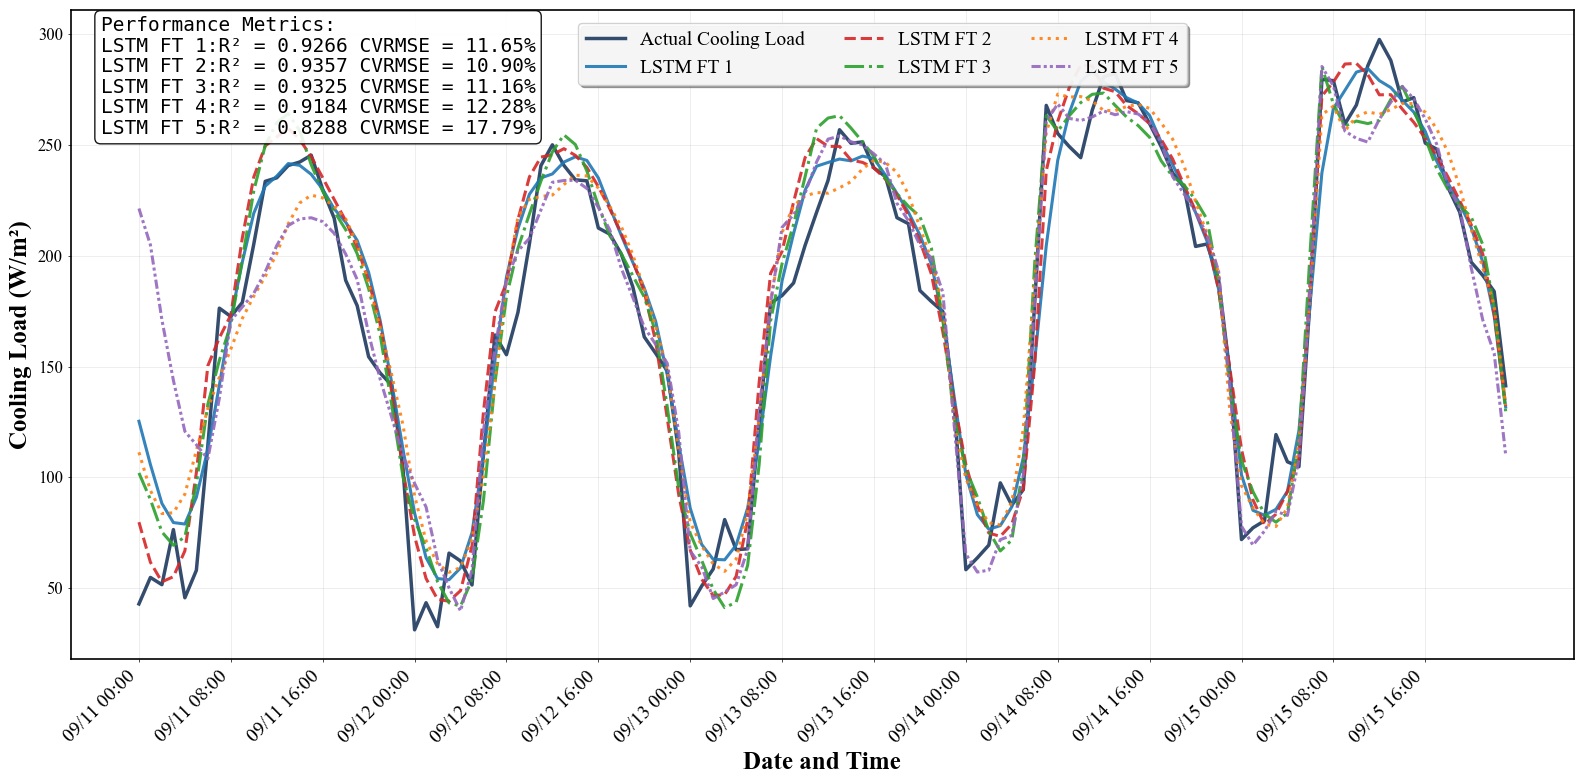

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import math

# ==================== 设置中文字体和样式 ====================
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.2

# ==================== 加载LSTM迁移学习模型的预测数据 ====================
# 加载LSTM迁移学习预测数据
lstm_models_data = []
model_names = []

# 加载前2个模型的预测数据
for i in range(1, 3):
    file_path = f"E:/bishe/BULL_lstm_transfer_learning_predictions{i}.csv"
    try:
        data = pd.read_csv(file_path, parse_dates=['timestamp'])
        lstm_models_data.append(data)
        model_names.append(f'LSTM FT {i}')
        print(f"成功加载模型 {i} 数据: {len(data)} 个数据点")
    except FileNotFoundError:
        print(f"警告: 找不到文件 {file_path}")
    except Exception as e:
        print(f"加载模型 {i} 数据时出错: {e}")

# 加载第三个模型（单独保存的文件）
try:
    data_3 = pd.read_csv("E:/bishe/BULL_lstm_transfer_learning_predictions.csv", parse_dates=['timestamp'])
    lstm_models_data.append(data_3)
    model_names.append('LSTM FT 3')
    print(f"成功加载模型 3 数据: {len(data_3)} 个数据点")
except FileNotFoundError:
    print("警告: 找不到文件 E:/bishe/BULL_lstm_transfer_learning_predictions.csv")
except Exception as e:
    print(f"加载模型 3 数据时出错: {e}")

# 加载第4和第5个模型的预测数据
for i in range(4, 6):
    file_path = f"E:/bishe/BULL_lstm_transfer_learning_predictions{i}.csv"
    try:
        data = pd.read_csv(file_path, parse_dates=['timestamp'])
        lstm_models_data.append(data)
        model_names.append(f'LSTM FT {i}')
        print(f"成功加载模型 {i} 数据: {len(data)} 个数据点")
    except FileNotFoundError:
        print(f"警告: 找不到文件 {file_path}")
    except Exception as e:
        print(f"加载模型 {i} 数据时出错: {e}")

# 检查是否成功加载了数据
if len(lstm_models_data) == 0:
    print("错误: 没有成功加载任何模型数据")
    exit()

# ==================== 确保时间戳对齐 ====================
# 找到所有数据集共有的时间戳
common_timestamps = set(lstm_models_data[0]['timestamp'])
for data in lstm_models_data[1:]:
    common_timestamps = common_timestamps.intersection(set(data['timestamp']))

print(f"\n共同时间戳数量: {len(common_timestamps)}")

# 筛选共同时间戳的数据
common_data_list = []
for data in lstm_models_data:
    common_data = data[data['timestamp'].isin(common_timestamps)].sort_values('timestamp').reset_index(drop=True)
    common_data_list.append(common_data)

# ==================== 计算所有模型的性能指标 ====================
performance_metrics = []

for i, data in enumerate(common_data_list):
    actual = data['actual'].values
    predicted = data['predicted'].values
    
    rmse = math.sqrt(mean_squared_error(actual, predicted))
    cvrmse = (rmse / np.mean(actual)) * 100
    r2 = r2_score(actual, predicted)
    mae = mean_absolute_error(actual, predicted)
    
    performance_metrics.append({
        'model': model_names[i],
        'rmse': rmse,
        'cvrmse': cvrmse,
        'r2': r2,
        'mae': mae
    })
    
    print(f"\n{model_names[i]} 性能指标:")
    print(f"  CVRMSE: {cvrmse:.2f}%")
    print(f"  R²: {r2:.4f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE: {mae:.2f}")

# ==================== 创建组合对比图 ====================
fig, ax = plt.subplots(figsize=(16, 8))
fig.subplots_adjust(top=0.90)

# 获取时间戳（使用第一个模型的时间戳）
timestamps = common_data_list[0]['timestamp']

# 定义颜色方案（5种不同颜色）
colors = ['#1F77B4', '#D62728', '#2CA02C', '#FF7F0E', '#9467BD']  # 蓝色，红色，绿色，橙色，紫色
line_styles = [
    '-',           # 实线
    '--',          # 虚线
    '-.',          # 点划线
    ':',           # 点线
    (0, (3, 1, 1, 1, 1, 1)),  # 自定义：短虚线
]

# 绘制实际负荷线（深蓝色实线）
actual_data = common_data_list[0]['actual'].values
line_actual, = ax.plot(timestamps, actual_data, 
                      label='Actual Cooling Load', 
                      color='#1E3A5F', linewidth=2.5, alpha=0.9)

# 绘制各个模型的预测线
model_lines = []
for i, data in enumerate(common_data_list):
    line, = ax.plot(timestamps, data['predicted'].values,
                   label=model_names[i],
                   color=colors[i], linewidth=2.2, alpha=0.9, linestyle=line_styles[i])
    model_lines.append(line)

# 格式化日期标签
date_labels = timestamps.dt.strftime('%m/%d %H:%M')
n = len(timestamps)
step = max(1, n // 15)

# 设置x轴刻度和标签
ax.set_xticks(timestamps[::step])
ax.set_xticklabels(date_labels[::step], rotation=45, ha='right', fontsize=14)
ax.set_xlabel('Date and Time', fontsize=18, fontweight='bold')

# 添加网格线
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# 设置y轴标签 - 修改这里：将m2改为m²
ax.set_ylabel('Cooling Load (W/m²)', fontsize=18, fontweight='bold')

# 添加图例 - 横排排列在图的最上方
ax.legend(loc='lower center', bbox_to_anchor=(0.54, 0.87), 
          frameon=True, fancybox=True, shadow=True, 
          framealpha=0.9, fontsize=14, ncol=3)

# ==================== 在左上方添加性能指标文本框 ====================
# 直接按顺序显示5个模型的性能指标
metrics_text = 'Performance Metrics:\n'
for i, metrics in enumerate(performance_metrics):
    if i == len(performance_metrics) - 1:  # 如果是最后一个模型，不添加换行符
        metrics_text += f"{metrics['model']}:R² = {metrics['r2']:.4f} CVRMSE = {metrics['cvrmse']:.2f}%"
    else:
        metrics_text += f"{metrics['model']}:R² = {metrics['r2']:.4f} CVRMSE = {metrics['cvrmse']:.2f}%\n"

# 创建文本框
bbox_props = dict(boxstyle='round', facecolor='white', alpha=0.9, 
                  edgecolor='black', linewidth=1)

# 使用linespacing参数减少行间距
ax.text(0.02, 0.99, metrics_text, transform=ax.transAxes, 
        verticalalignment='top', 
        bbox=bbox_props, 
        fontsize=14,
        fontfamily='monospace',
        linespacing=1.1)



# 调整布局
plt.tight_layout()

# 保存为高质量图像
plt.savefig("E:/bishe/LSTM_Transfer_Learning_Comparison.svg", format='svg', dpi=300, bbox_inches='tight')
plt.savefig("E:/bishe/LSTM_Transfer_Learning_Comparison.png", dpi=300, bbox_inches='tight')

print("\n对比图已保存至:")
print(" - E:/bishe/LSTM_Transfer_Learning_Comparison.svg")
print(" - E:/bishe/LSTM_Transfer_Learning_Comparison.png")

plt.show()

共同数据点: 120

合并对比图已保存至:
 - E:/bishe/Combined_Models_Comparison.svg
 - E:/bishe/Combined_Models_Comparison.png


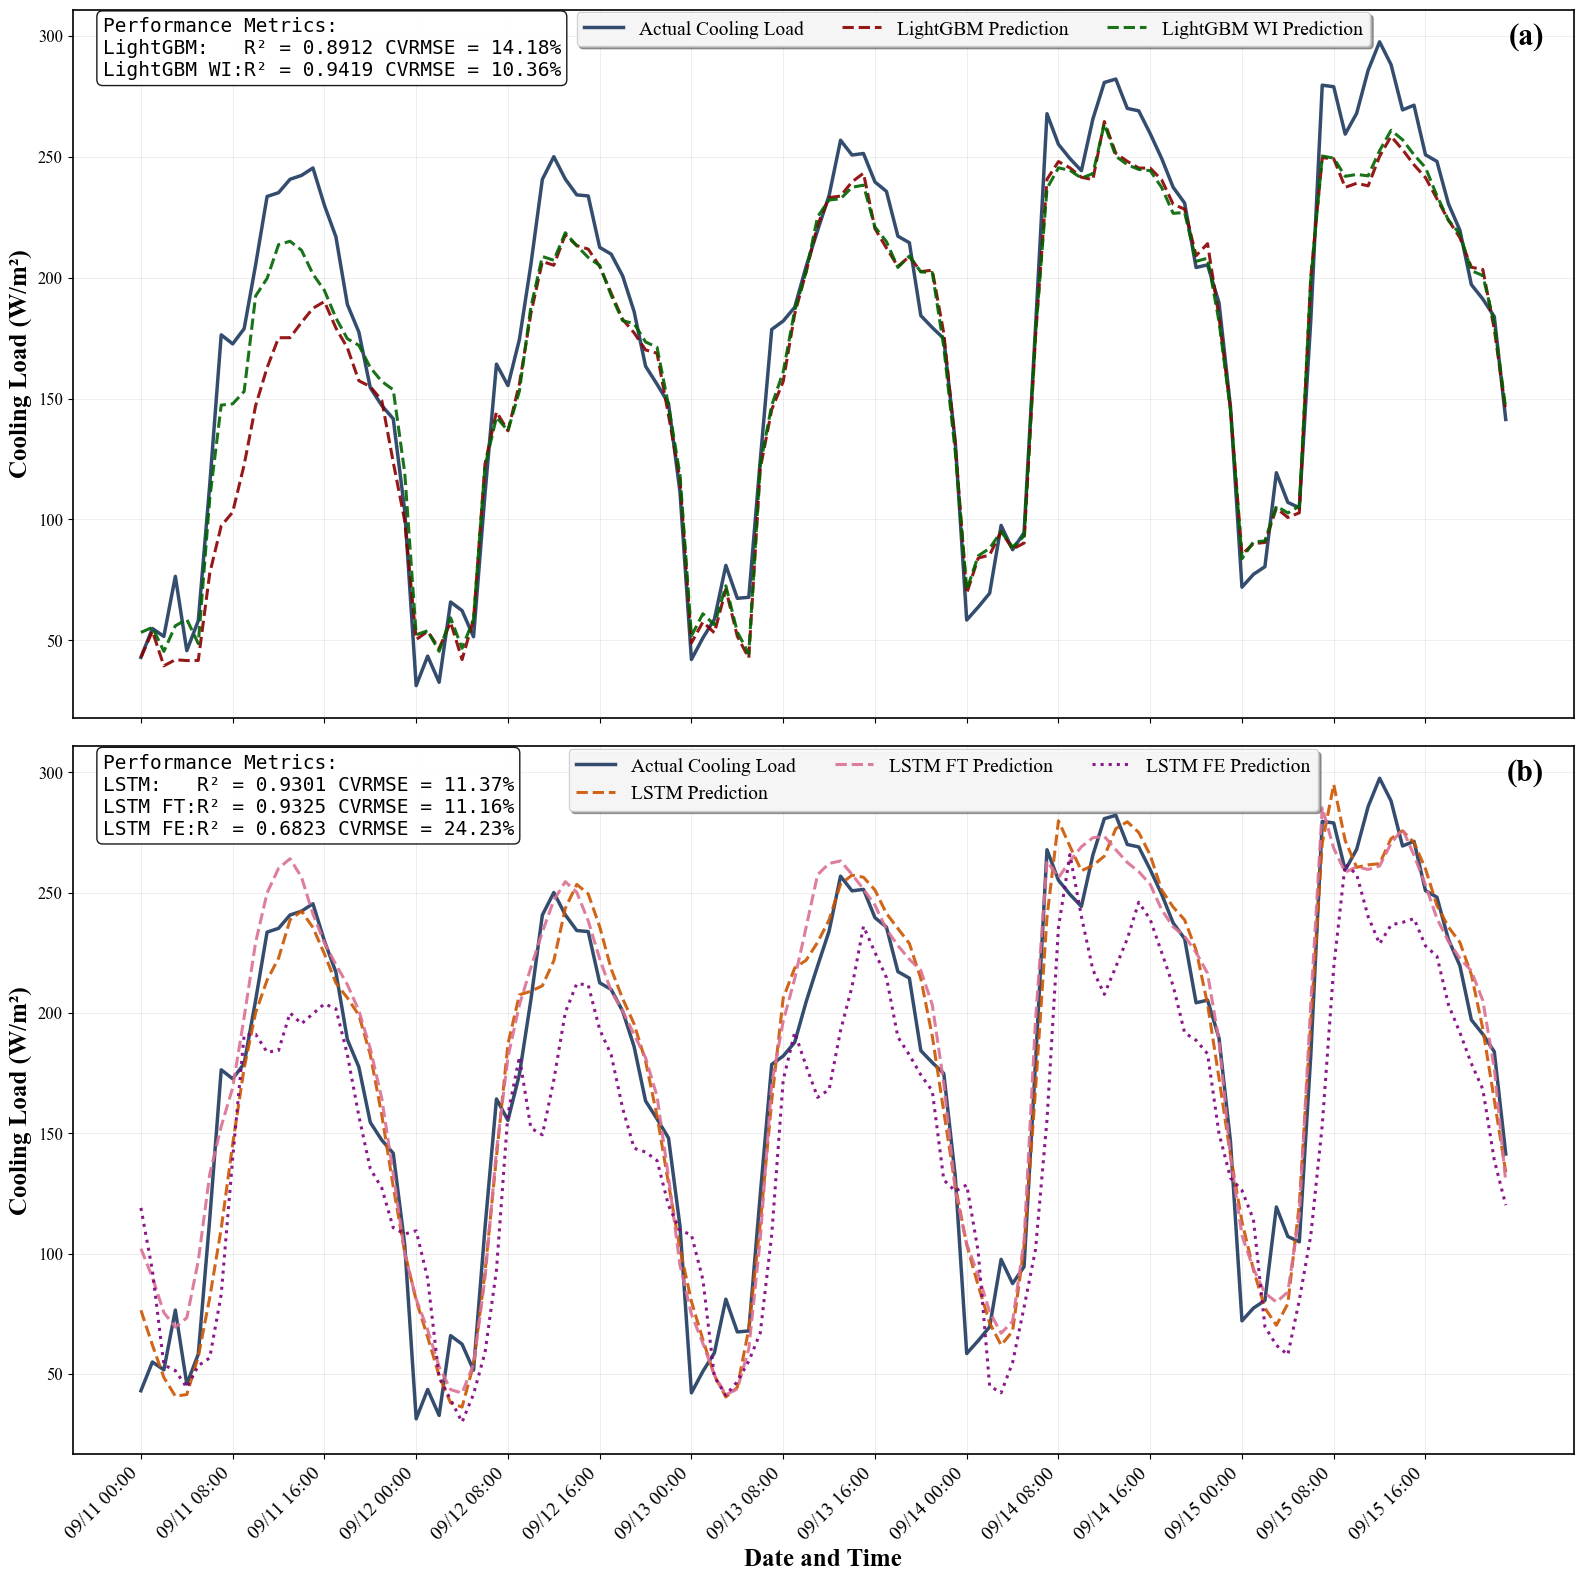

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import math

# ==================== 设置中文字体和样式 ====================
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.2

# ==================== 加载所有模型的预测数据 ====================
# 加载LightGBM相关数据
lgb_data = pd.read_csv("E:/bishe/BULL_lightgbm_predictions.csv", parse_dates=['timestamp'])
transfer_data = pd.read_csv("E:/bishe/transfer_learning_predictions.csv", parse_dates=['timestamp'])

# 加载LSTM相关数据
lstm_data = pd.read_csv("E:/bishe/Bull_LSTM_predictions.csv", parse_dates=['timestamp'])
lstm_finetune_data = pd.read_csv("E:/bishe/BULL_lstm_transfer_learning_predictions.csv", parse_dates=['timestamp'])
lstm_feature_data = pd.read_csv("E:/bishe/BULL_lstm_feature_extract_predictions.csv", parse_dates=['timestamp'])

# ==================== 找到所有数据集共有的时间戳 ====================
# 找到所有数据集共有的时间戳
all_timestamps = set(lgb_data['timestamp']).intersection(
    set(transfer_data['timestamp']),
    set(lstm_data['timestamp']),
    set(lstm_finetune_data['timestamp']),
    set(lstm_feature_data['timestamp'])
)

# 筛选共同时间戳的数据
lgb_common = lgb_data[lgb_data['timestamp'].isin(all_timestamps)].sort_values('timestamp').reset_index(drop=True)
transfer_common = transfer_data[transfer_data['timestamp'].isin(all_timestamps)].sort_values('timestamp').reset_index(drop=True)
lstm_common = lstm_data[lstm_data['timestamp'].isin(all_timestamps)].sort_values('timestamp').reset_index(drop=True)
lstm_finetune_common = lstm_finetune_data[lstm_finetune_data['timestamp'].isin(all_timestamps)].sort_values('timestamp').reset_index(drop=True)
lstm_feature_common = lstm_feature_data[lstm_feature_data['timestamp'].isin(all_timestamps)].sort_values('timestamp').reset_index(drop=True)

print(f"共同数据点: {len(all_timestamps)}")

# ==================== 计算所有模型的性能指标 ====================
# LightGBM模型指标
lgb_actual = lgb_common['actual'].values
lgb_predicted = lgb_common['predicted'].values
lgb_rmse = math.sqrt(mean_squared_error(lgb_actual, lgb_predicted))
lgb_cvrmse = (lgb_rmse / np.mean(lgb_actual)) * 100
lgb_r2 = r2_score(lgb_actual, lgb_predicted)

# 迁移学习LightGBM指标
transfer_actual = transfer_common['actual'].values
transfer_predicted = transfer_common['predicted'].values
transfer_rmse = math.sqrt(mean_squared_error(transfer_actual, transfer_predicted))
transfer_cvrmse = (transfer_rmse / np.mean(transfer_actual)) * 100
transfer_r2 = r2_score(transfer_actual, transfer_predicted)

# LSTM模型指标
lstm_actual = lstm_common['actual'].values
lstm_predicted = lstm_common['predicted'].values
lstm_rmse = math.sqrt(mean_squared_error(lstm_actual, lstm_predicted))
lstm_cvrmse = (lstm_rmse / np.mean(lstm_actual)) * 100
lstm_r2 = r2_score(lstm_actual, lstm_predicted)

# LSTM微调指标
lstm_finetune_actual = lstm_finetune_common['actual'].values
lstm_finetune_predicted = lstm_finetune_common['predicted'].values
lstm_finetune_rmse = math.sqrt(mean_squared_error(lstm_finetune_actual, lstm_finetune_predicted))
lstm_finetune_cvrmse = (lstm_finetune_rmse / np.mean(lstm_finetune_actual)) * 100
lstm_finetune_r2 = r2_score(lstm_finetune_actual, lstm_finetune_predicted)

# LSTM特征提取指标
lstm_feature_actual = lstm_feature_common['actual'].values
lstm_feature_predicted = lstm_feature_common['predicted'].values
lstm_feature_rmse = math.sqrt(mean_squared_error(lstm_feature_actual, lstm_feature_predicted))
lstm_feature_cvrmse = (lstm_feature_rmse / np.mean(lstm_feature_actual)) * 100
lstm_feature_r2 = r2_score(lstm_feature_actual, lstm_feature_predicted)

# ==================== 创建组合图 ====================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 16))
fig.subplots_adjust(top=0.95, hspace=0.15)

# 获取共同的时间戳
timestamps = lgb_common['timestamp']

# ==================== 第一个子图：LightGBM模型对比 ====================
ax1.text(0.98, 0.98, '(a)', transform=ax1.transAxes,
         verticalalignment='top', horizontalalignment='right',
         fontsize=22, fontweight='bold')
# 绘制实际负荷线（深蓝色实线）
line_actual1, = ax1.plot(timestamps, lgb_actual, 
                        label='Actual Cooling Load', 
                        color='#1E3A5F', linewidth=2.5, alpha=0.9)

# 绘制普通LightGBM预测线（深红色虚线）
line_lgb, = ax1.plot(timestamps, lgb_predicted, 
                    label='LightGBM Prediction', 
                    color='#8B0000', linewidth=2.2, alpha=0.9, linestyle='--')

# 绘制迁移学习LightGBM预测线（深绿色虚线）
line_transfer, = ax1.plot(timestamps, transfer_predicted, 
                         label='LightGBM WI Prediction', 
                         color='#006400', linewidth=2.2, alpha=0.9, linestyle='--')

# 格式化日期标签
date_labels = timestamps.dt.strftime('%m/%d %H:%M')
n = len(timestamps)
step = max(1, n // 15)

# 设置x轴刻度和标签 - 隐藏第一个子图的x轴标签
ax1.set_xticks(timestamps[::step])
ax1.set_xticklabels([])  # 隐藏x轴刻度标签


# 添加网格线
ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax1.set_axisbelow(True)

# 设置y轴标签 - 修改这里：将m2改为m²
ax1.set_ylabel('Cooling Load (W/m²)', fontsize=18, fontweight='bold')

# 添加图例 - 横排排列在图的最上方
ax1.legend(loc='lower center', bbox_to_anchor=(0.6, 0.935), 
          frameon=True, fancybox=True, shadow=True, 
          framealpha=0.9, fontsize=14, ncol=3)

# 在左上方添加性能指标文本框
metrics_text1 = (
    f'Performance Metrics:\n'
    f'LightGBM:   R² = {lgb_r2:.4f} CVRMSE = {lgb_cvrmse:.2f}%\n'
    f'LightGBM WI:R² = {transfer_r2:.4f} CVRMSE = {transfer_cvrmse:.2f}%'
)

# 创建文本框
bbox_props1 = dict(boxstyle='round', facecolor='white', alpha=0.9, 
                  edgecolor='black', linewidth=1)

# 使用linespacing参数减少行间距
ax1.text(0.02, 0.99, metrics_text1, transform=ax1.transAxes, 
        verticalalignment='top', 
        bbox=bbox_props1, 
        fontsize=14,
        fontfamily='monospace',
        linespacing=1.2)

# ==================== 第二个子图：LSTM模型对比 ====================
ax2.text(0.98, 0.98, '(b)', transform=ax2.transAxes,
         verticalalignment='top', horizontalalignment='right',
         fontsize=22, fontweight='bold')
# 绘制实际负荷线（深蓝色实线）
line_actual2, = ax2.plot(timestamps, lstm_actual, 
                        label='Actual Cooling Load', 
                        color='#1E3A5F', linewidth=2.5, alpha=0.9)

# 绘制普通LSTM预测线（#CC5500色虚线）
line_lstm, = ax2.plot(timestamps, lstm_predicted, 
                     label='LSTM Prediction', 
                     color='#CC5500', linewidth=2.2, alpha=0.9, linestyle='--')

# 绘制LSTM微调预测线（浅粉色虚线）
line_finetune, = ax2.plot(timestamps, lstm_finetune_predicted, 
                         label='LSTM FT Prediction', 
                         color='#DB7093', linewidth=2.2, alpha=0.9, linestyle='--')

# 绘制LSTM特征提取预测线（正常紫色虚线）
line_feature, = ax2.plot(timestamps, lstm_feature_predicted, 
                        label='LSTM FE Prediction', 
                        color='#800080', linewidth=2.2, alpha=0.9, linestyle=':')

# 格式化日期标签
date_labels = timestamps.dt.strftime('%m/%d %H:%M')
n = len(timestamps)
step = max(1, n // 15)

# 设置x轴刻度和标签
ax2.set_xticks(timestamps[::step])
ax2.set_xticklabels(date_labels[::step], rotation=45, ha='right', fontsize=14)
ax2.set_xlabel('Date and Time', fontsize=18, fontweight='bold')

# 添加网格线
ax2.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax2.set_axisbelow(True)

# 设置y轴标签 - 修改这里：将m2改为m²
ax2.set_ylabel('Cooling Load (W/m²)', fontsize=18, fontweight='bold')

# 添加图例 - 横排排列在图的最上方
ax2.legend(loc='lower center', bbox_to_anchor=(0.58, 0.895), 
          frameon=True, fancybox=True, shadow=True, 
          framealpha=0.9, fontsize=14, ncol=3)

# 在左上方添加性能指标文本框
metrics_text2 = (
    f'Performance Metrics:\n'
    f'LSTM:   R² = {lstm_r2:.4f} CVRMSE = {lstm_cvrmse:.2f}%\n'
    f'LSTM FT:R² = {lstm_finetune_r2:.4f} CVRMSE = {lstm_finetune_cvrmse:.2f}%\n'
    f'LSTM FE:R² = {lstm_feature_r2:.4f} CVRMSE = {lstm_feature_cvrmse:.2f}%'
)

# 创建文本框
bbox_props2 = dict(boxstyle='round', facecolor='white', alpha=0.9, 
                  edgecolor='black', linewidth=1)

# 使用linespacing参数减少行间距
ax2.text(0.02, 0.99, metrics_text2, transform=ax2.transAxes, 
        verticalalignment='top', 
        bbox=bbox_props2, 
        fontsize=14,
        fontfamily='monospace',
        linespacing=1.2)

# ==================== 保存图像 ====================
plt.tight_layout()
plt.savefig("E:/bishe/Combined_Models_Comparison.svg", format='svg', dpi=300, bbox_inches='tight')
plt.savefig("E:/bishe/Combined_Models_Comparison.png", dpi=300, bbox_inches='tight')

print("\n合并对比图已保存至:")
print(" - E:/bishe/Combined_Models_Comparison.svg")
print(" - E:/bishe/Combined_Models_Comparison.png")

plt.show()

共同数据点: 120

合并对比图已保存至:
 - E:/bishe/Transfer_Learning_Comparison.svg
 - E:/bishe/Transfer_Learning_Comparison.png


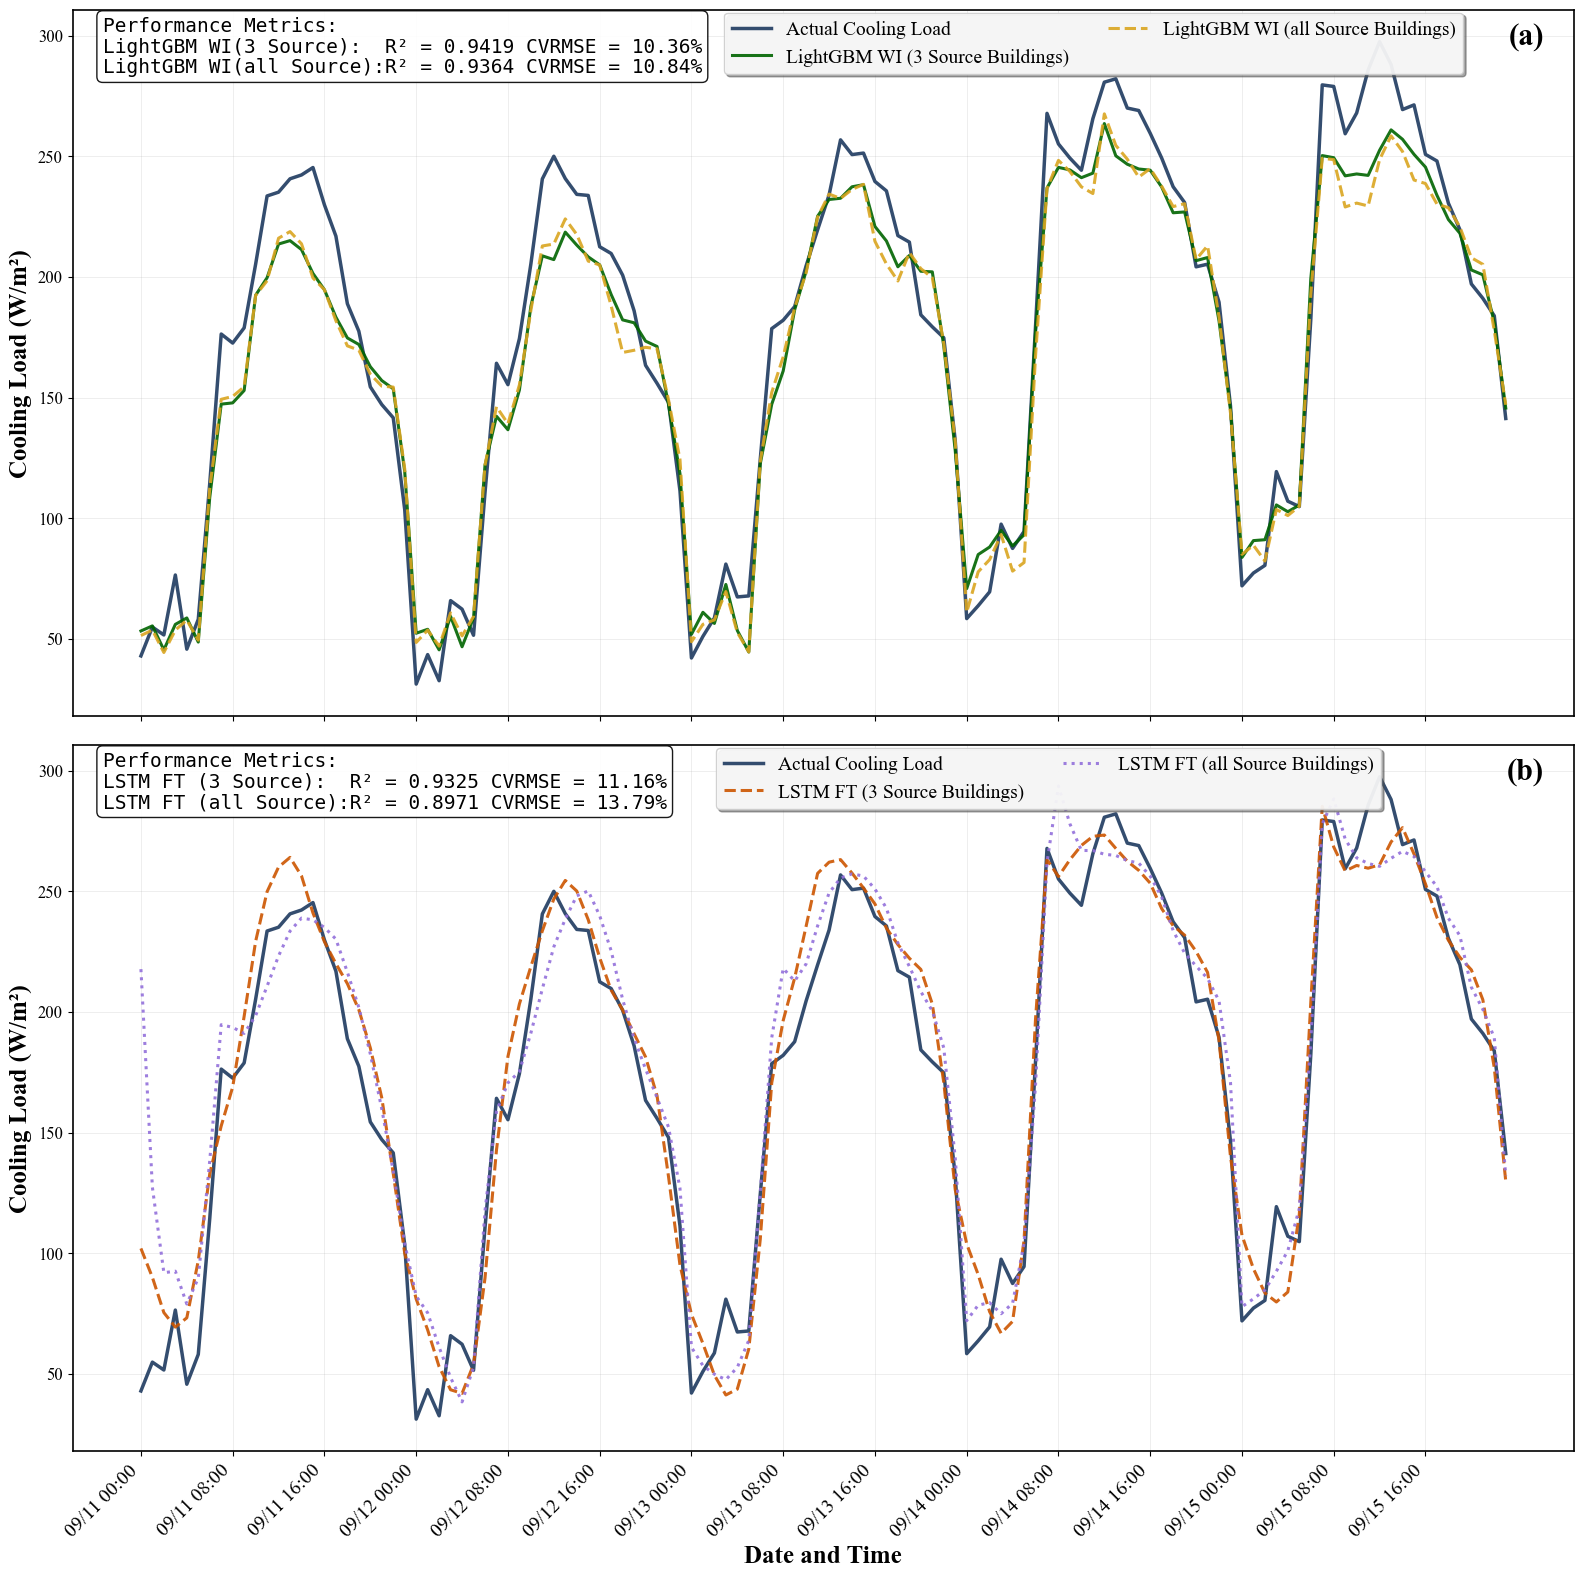

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import math

# ==================== 设置中文字体和样式 ====================
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.2

# ==================== 加载所有模型的预测数据 ====================
# 加载LightGBM相关数据
lgb_finetune_data = pd.read_csv("E:/bishe/transfer_learning_predictions.csv", parse_dates=['timestamp'])
lgb_full_source_data = pd.read_csv("E:/bishe/transfer_learning_full_source_predictions.csv", parse_dates=['timestamp'])

# 加载LSTM相关数据
lstm_finetune_data = pd.read_csv("E:/bishe/BULL_lstm_transfer_learning_predictions.csv", parse_dates=['timestamp'])
lstm_full_source_data = pd.read_csv("E:/bishe/BULL_lstm_全源域_transfer_learning_predictions.csv", parse_dates=['timestamp'])

# ==================== 找到所有数据集共有的时间戳 ====================
# 找到所有数据集共有的时间戳
all_timestamps = set(lgb_finetune_data['timestamp']).intersection(
    set(lgb_full_source_data['timestamp']),
    set(lstm_finetune_data['timestamp']),
    set(lstm_full_source_data['timestamp'])
)

# 筛选共同时间戳的数据
lgb_finetune_common = lgb_finetune_data[lgb_finetune_data['timestamp'].isin(all_timestamps)].sort_values('timestamp').reset_index(drop=True)
lgb_full_source_common = lgb_full_source_data[lgb_full_source_data['timestamp'].isin(all_timestamps)].sort_values('timestamp').reset_index(drop=True)
lstm_finetune_common = lstm_finetune_data[lstm_finetune_data['timestamp'].isin(all_timestamps)].sort_values('timestamp').reset_index(drop=True)
lstm_full_source_common = lstm_full_source_data[lstm_full_source_data['timestamp'].isin(all_timestamps)].sort_values('timestamp').reset_index(drop=True)

print(f"共同数据点: {len(all_timestamps)}")

# ==================== 计算所有模型的性能指标 ====================
# LightGBM迁移学习指标（3源建筑）
lgb_finetune_actual = lgb_finetune_common['actual'].values
lgb_finetune_predicted = lgb_finetune_common['predicted'].values
lgb_finetune_rmse = math.sqrt(mean_squared_error(lgb_finetune_actual, lgb_finetune_predicted))
lgb_finetune_cvrmse = (lgb_finetune_rmse / np.mean(lgb_finetune_actual)) * 100
lgb_finetune_r2 = r2_score(lgb_finetune_actual, lgb_finetune_predicted)

# LightGBM全源域迁移学习指标（6源建筑）
lgb_full_source_actual = lgb_full_source_common['actual'].values
lgb_full_source_predicted = lgb_full_source_common['predicted'].values
lgb_full_source_rmse = math.sqrt(mean_squared_error(lgb_full_source_actual, lgb_full_source_predicted))
lgb_full_source_cvrmse = (lgb_full_source_rmse / np.mean(lgb_full_source_actual)) * 100
lgb_full_source_r2 = r2_score(lgb_full_source_actual, lgb_full_source_predicted)

# LSTM微调指标（3源建筑）
lstm_finetune_actual = lstm_finetune_common['actual'].values
lstm_finetune_predicted = lstm_finetune_common['predicted'].values
lstm_finetune_rmse = math.sqrt(mean_squared_error(lstm_finetune_actual, lstm_finetune_predicted))
lstm_finetune_cvrmse = (lstm_finetune_rmse / np.mean(lstm_finetune_actual)) * 100
lstm_finetune_r2 = r2_score(lstm_finetune_actual, lstm_finetune_predicted)

# LSTM全源域微调指标（6源建筑）
lstm_full_source_actual = lstm_full_source_common['actual'].values
lstm_full_source_predicted = lstm_full_source_common['predicted'].values
lstm_full_source_rmse = math.sqrt(mean_squared_error(lstm_full_source_actual, lstm_full_source_predicted))
lstm_full_source_cvrmse = (lstm_full_source_rmse / np.mean(lstm_full_source_actual)) * 100
lstm_full_source_r2 = r2_score(lstm_full_source_actual, lstm_full_source_predicted)

# ==================== 创建组合图 ====================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 16))
fig.subplots_adjust(top=0.95, hspace=0.15)

# 获取共同的时间戳
timestamps = lgb_finetune_common['timestamp']

# ==================== 第一个子图：LightGBM迁移学习模型对比 ====================
ax1.text(0.98, 0.98, '(a)', transform=ax1.transAxes,
         verticalalignment='top', horizontalalignment='right',
         fontsize=22, fontweight='bold')
# 绘制实际负荷线（深蓝色实线）
line_actual1, = ax1.plot(timestamps, lgb_finetune_actual, 
                        label='Actual Cooling Load', 
                        color='#1E3A5F', linewidth=2.5, alpha=0.9)

# 绘制LightGBM迁移学习预测线（绿色虚线）
line_finetune, = ax1.plot(timestamps, lgb_finetune_predicted, 
                         label='LightGBM WI (3 Source Buildings)', 
                         color='#006400', linewidth=2.2, alpha=0.9, linestyle='-')

# 绘制LightGBM全源域迁移学习预测线（金色虚线）
line_full_source, = ax1.plot(timestamps, lgb_full_source_predicted, 
                            label='LightGBM WI (all Source Buildings)', 
                            color='#DAA520', linewidth=2.2, alpha=0.9, linestyle='--')

# 格式化日期标签
date_labels = timestamps.dt.strftime('%m/%d %H:%M')
n = len(timestamps)
step = max(1, n // 15)

# 设置x轴刻度和标签 - 隐藏第一个子图的x轴标签
ax1.set_xticks(timestamps[::step])
ax1.set_xticklabels([])  # 隐藏x轴刻度标签

# 添加网格线
ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax1.set_axisbelow(True)

# 设置y轴标签 - 修改这里：将m2改为m²
ax1.set_ylabel('Cooling Load (W/m²)', fontsize=18, fontweight='bold')

# 添加图例 - 横排排列在图的最上方
ax1.legend(loc='lower center', bbox_to_anchor=(0.68, 0.895), 
          frameon=True, fancybox=True, shadow=True, 
          framealpha=0.9, fontsize=14, ncol=2)

# 在左上方添加性能指标文本框
metrics_text1 = (
    f'Performance Metrics:\n'
    f'LightGBM WI(3 Source):  R² = {lgb_finetune_r2:.4f} CVRMSE = {lgb_finetune_cvrmse:.2f}%\n'
    f'LightGBM WI(all Source):R² = {lgb_full_source_r2:.4f} CVRMSE = {lgb_full_source_cvrmse:.2f}%'
)

# 创建文本框
bbox_props1 = dict(boxstyle='round', facecolor='white', alpha=0.9, 
                  edgecolor='black', linewidth=1)

# 使用linespacing参数减少行间距
ax1.text(0.02, 0.99, metrics_text1, transform=ax1.transAxes, 
        verticalalignment='top', 
        bbox=bbox_props1, 
        fontsize=14,
        fontfamily='monospace',
        linespacing=1.1)

# ==================== 第二个子图：LSTM迁移学习模型对比 ====================
ax2.text(0.98, 0.98, '(b)', transform=ax2.transAxes,
         verticalalignment='top', horizontalalignment='right',
         fontsize=22, fontweight='bold')
# 绘制实际负荷线（深蓝色实线）
line_actual2, = ax2.plot(timestamps, lstm_finetune_actual, 
                        label='Actual Cooling Load', 
                        color='#1E3A5F', linewidth=2.5, alpha=0.9)

# 绘制LSTM微调预测线（橙色虚线）
line_finetune2, = ax2.plot(timestamps, lstm_finetune_predicted, 
                          label='LSTM FT (3 Source Buildings)', 
                          color='#CC5500', linewidth=2.2, alpha=0.9, linestyle='--')

# 绘制LSTM全源域微调预测线（紫色虚线）
line_full_source2, = ax2.plot(timestamps, lstm_full_source_predicted, 
                             label='LSTM FT (all Source Buildings)', 
                             color='#9370DB', linewidth=2.2, alpha=0.9, linestyle=':')

# 格式化日期标签
date_labels = timestamps.dt.strftime('%m/%d %H:%M')
n = len(timestamps)
step = max(1, n // 15)

# 设置x轴刻度和标签
ax2.set_xticks(timestamps[::step])
ax2.set_xticklabels(date_labels[::step], rotation=45, ha='right', fontsize=14)
ax2.set_xlabel('Date and Time', fontsize=18, fontweight='bold')

# 添加网格线
ax2.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax2.set_axisbelow(True)

# 设置y轴标签 - 修改这里：将m2改为m²
ax2.set_ylabel('Cooling Load (W/m²)', fontsize=18, fontweight='bold')

# 添加图例 - 横排排列在图的最上方
ax2.legend(loc='lower center', bbox_to_anchor=(0.65, 0.895), 
          frameon=True, fancybox=True, shadow=True, 
          framealpha=0.9, fontsize=14, ncol=2)

# 在左上方添加性能指标文本框
metrics_text2 = (
    f'Performance Metrics:\n'
    f'LSTM FT (3 Source):  R² = {lstm_finetune_r2:.4f} CVRMSE = {lstm_finetune_cvrmse:.2f}%\n'
    f'LSTM FT (all Source):R² = {lstm_full_source_r2:.4f} CVRMSE = {lstm_full_source_cvrmse:.2f}%'
)

# 创建文本框
bbox_props2 = dict(boxstyle='round', facecolor='white', alpha=0.9, 
                  edgecolor='black', linewidth=1)

# 使用linespacing参数减少行间距
ax2.text(0.02, 0.99, metrics_text2, transform=ax2.transAxes, 
        verticalalignment='top', 
        bbox=bbox_props2, 
        fontsize=14,
        fontfamily='monospace',
        linespacing=1.1)

# ==================== 保存图像 ====================
plt.tight_layout()
plt.savefig("E:/bishe/Transfer_Learning_Comparison.svg", format='svg', dpi=300, bbox_inches='tight')
plt.savefig("E:/bishe/Transfer_Learning_Comparison.png", dpi=300, bbox_inches='tight')

print("\n合并对比图已保存至:")
print(" - E:/bishe/Transfer_Learning_Comparison.svg")
print(" - E:/bishe/Transfer_Learning_Comparison.png")

plt.show()


SCI级误差分析图已保存至:
 - E:/bishe/SCI_Error_Distribution_Analysis.svg
 - E:/bishe/SCI_Error_Distribution_Analysis.png


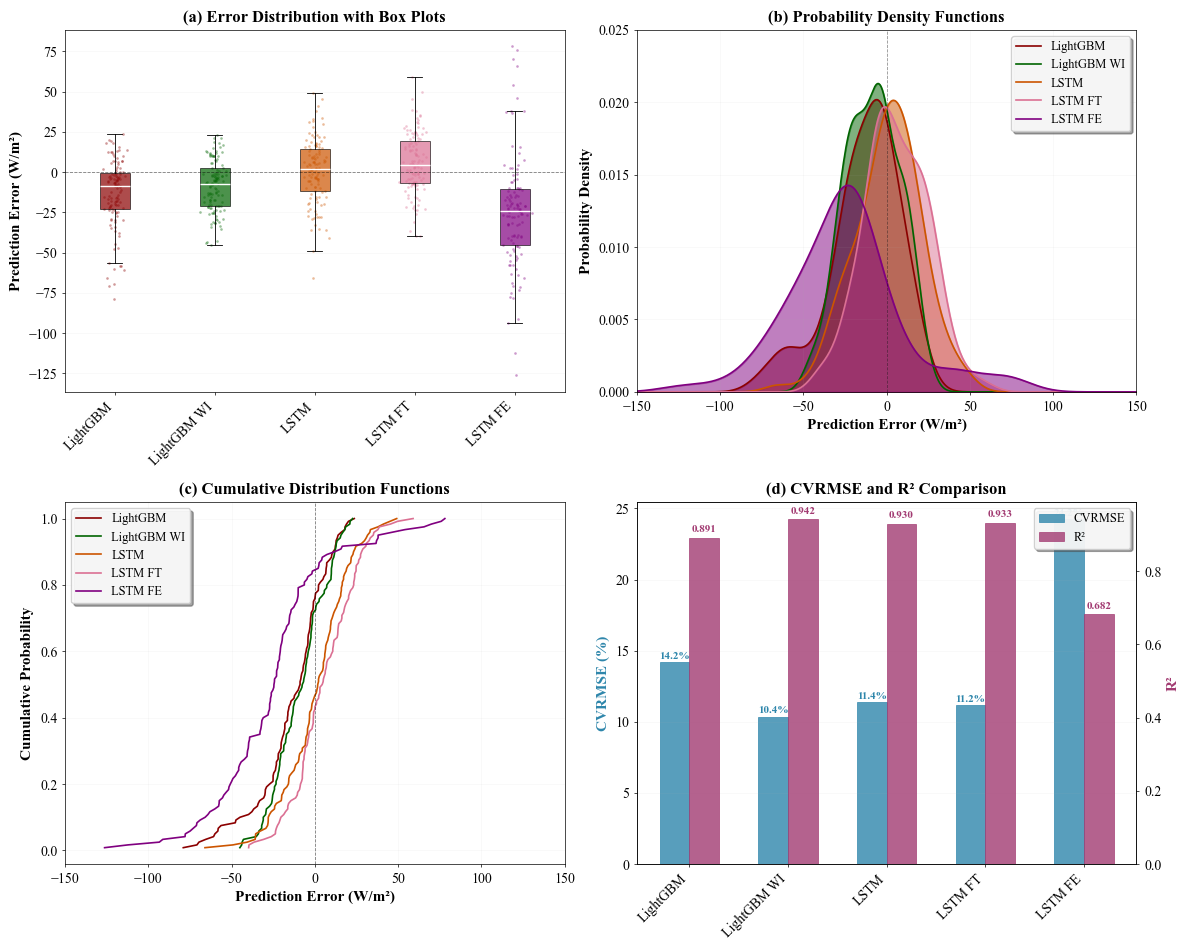


MODEL ERROR STATISTICAL ANALYSIS

LightGBM:
  Mean Error: -13.45 ± 21.09 W/m²
  RMSE: 24.94 W/m²
  CVRMSE: 14.18%
  R²: 0.8912
  MAE: 18.26 W/m²
  Error Range: [-78.97, 23.73] W/m²
  Skewness: -0.891
  Kurtosis: 0.693
  Normality (p=0.0003): Non-normal

LightGBM WI:
  Mean Error: -8.81 ± 16.02 W/m²
  RMSE: 18.23 W/m²
  CVRMSE: 10.36%
  R²: 0.9419
  MAE: 14.86 W/m²
  Error Range: [-44.99, 22.76] W/m²
  Skewness: -0.102
  Kurtosis: -0.710
  Normality (p=0.0787): Normal

LSTM:
  Mean Error: 0.66 ± 20.07 W/m²
  RMSE: 20.00 W/m²
  CVRMSE: 11.37%
  R²: 0.9301
  MAE: 15.70 W/m²
  Error Range: [-65.95, 49.22] W/m²
  Skewness: -0.321
  Kurtosis: 0.375
  Normality (p=0.1872): Normal

LSTM FT:
  Mean Error: 5.53 ± 18.93 W/m²
  RMSE: 19.64 W/m²
  CVRMSE: 11.16%
  R²: 0.9325
  MAE: 15.62 W/m²
  Error Range: [-39.71, 59.06] W/m²
  Skewness: 0.059
  Kurtosis: -0.110
  Normality (p=0.9620): Normal

LSTM FE:
  Mean Error: -24.91 ± 34.74 W/m²
  RMSE: 42.63 W/m²
  CVRMSE: 24.23%
  R²: 0.6823
  MAE: 35.0

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import math

# ==================== 设置SCI论文级别的样式 ====================
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['xtick.major.size'] = 2
plt.rcParams['ytick.major.size'] = 2

# ==================== 加载数据 ====================
lgb_data = pd.read_csv('E:/bishe/BULL_lightgbm_predictions.csv', parse_dates=['timestamp'])
transfer_data = pd.read_csv('E:/bishe/transfer_learning_predictions.csv', parse_dates=['timestamp'])
lstm_data = pd.read_csv('E:/bishe/Bull_LSTM_predictions.csv', parse_dates=['timestamp'])
lstm_finetune_data = pd.read_csv('E:/bishe/BULL_lstm_transfer_learning_predictions.csv', parse_dates=['timestamp'])
lstm_feature_data = pd.read_csv('E:/bishe/BULL_lstm_feature_extract_predictions.csv', parse_dates=['timestamp'])

# ==================== 数据处理 ====================
all_timestamps = set(lgb_data['timestamp']).intersection(
    set(transfer_data['timestamp']), set(lstm_data['timestamp']),
    set(lstm_finetune_data['timestamp']), set(lstm_feature_data['timestamp'])
)

lgb_common = lgb_data[lgb_data['timestamp'].isin(all_timestamps)].sort_values('timestamp').reset_index(drop=True)
transfer_common = transfer_data[transfer_data['timestamp'].isin(all_timestamps)].sort_values('timestamp').reset_index(drop=True)
lstm_common = lstm_data[lstm_data['timestamp'].isin(all_timestamps)].sort_values('timestamp').reset_index(drop=True)
lstm_finetune_common = lstm_finetune_data[lstm_finetune_data['timestamp'].isin(all_timestamps)].sort_values('timestamp').reset_index(drop=True)
lstm_feature_common = lstm_feature_data[lstm_feature_data['timestamp'].isin(all_timestamps)].sort_values('timestamp').reset_index(drop=True)

# 计算误差
lgb_errors = lgb_common['predicted'] - lgb_common['actual']
transfer_errors = transfer_common['predicted'] - transfer_common['actual']
lstm_errors = lstm_common['predicted'] - lstm_common['actual']
lstm_finetune_errors = lstm_finetune_common['predicted'] - lstm_finetune_common['actual']
lstm_feature_errors = lstm_feature_common['predicted'] - lstm_feature_common['actual']

# ==================== 创建专业级误差分布图 ====================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))


# 定义模型名称和对应的误差数据
models = {
    'LightGBM': lgb_errors,
    'LightGBM WI': transfer_errors,
    'LSTM': lstm_errors,
    'LSTM FT': lstm_finetune_errors,
    'LSTM FE': lstm_feature_errors
}

colors = ['#8B0000', '#006400', '#CC5500', '#DB7093', '#800080']

# ==================== 子图1：箱线图 + 蜂群图 ====================
for i, (model_name, errors) in enumerate(models.items()):
    # 箱线图 - 修长样式，参考范例图比例
    bp = axes[0,0].boxplot(errors, positions=[i], widths=0.3, patch_artist=True, 
                          showfliers=False, whiskerprops=dict(linewidth=0.6), 
                          capprops=dict(linewidth=0.6), medianprops=dict(linewidth=1.0, color='white'),
                          boxprops=dict(linewidth=0.6))
    
    # 设置箱线图颜色和透明度 - 参考范例图透明度
    bp['boxes'][0].set_facecolor(colors[i])
    bp['boxes'][0].set_alpha(0.7)
    
    # 添加蜂群图 - 提高清晰度，参考范例图点的大小和密度
    x_jittered = np.random.normal(i, 0.05, size=len(errors))
    axes[0,0].scatter(x_jittered, errors, alpha=0.4, s=14, color=colors[i], linewidth=0, marker='.')

# 参考范例图的零线样式
axes[0,0].axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=0.6)
axes[0,0].set_xticks(range(len(models)))
axes[0,0].set_xticklabels(list(models.keys()), rotation=45, ha='right')
# 修改这里：将m2改为m²
axes[0,0].set_ylabel('Prediction Error (W/m²)', fontsize=11, fontweight='bold')
axes[0,0].set_title('(a) Error Distribution with Box Plots', fontsize=12, fontweight='bold')
# 参考范例图的网格样式
axes[0,0].grid(True, alpha=0.1, axis='y', linestyle='-', linewidth=0.5)

# ==================== 子图2：概率密度图 - 严格按照范例图调整 ====================
for i, (model_name, errors) in enumerate(models.items()):
    # 使用核密度估计 - 参考范例图的曲线平滑度
    kde = stats.gaussian_kde(errors)
    # 调整x范围以匹配范例图的比例
    x_range = np.linspace(-150, 150, 400)  # 参考范例图的x轴范围
    y_range = kde(x_range)
    axes[0,1].plot(x_range, y_range, color=colors[i], linewidth=1.2, label=model_name)
    # 填充曲线下方区域 - 参考范例图的透明度
    axes[0,1].fill_between(x_range, y_range, alpha=0.5, color=colors[i])

# 参考范例图的零线和坐标轴样式
axes[0,1].axvline(x=0, color='black', linestyle='--', alpha=0.4, linewidth=0.6)
# 修改这里：将m2改为m²
axes[0,1].set_xlabel('Prediction Error (W/m²)', fontsize=11, fontweight='bold')
axes[0,1].set_ylabel('Probability Density', fontsize=11, fontweight='bold')
axes[0,1].set_title('(b) Probability Density Functions', fontsize=12, fontweight='bold')
# 参考范例图的y轴范围
axes[0,1].set_ylim(0, 0.025)  # 匹配范例图的y轴范围
axes[0,1].set_xlim(-150, 150)  # 匹配范例图的x轴范围
axes[0,1].legend(fontsize=9, frameon=True, fancybox=True, shadow=True, framealpha=0.9)
axes[0,1].grid(True, alpha=0.1, linestyle='-', linewidth=0.5)

# ==================== 子图3：累积分布函数 - 参考范例图比例 ====================
for i, (model_name, errors) in enumerate(models.items()):
    sorted_errors = np.sort(errors)
    cdf = np.arange(1, len(sorted_errors)+1) / len(sorted_errors)
    axes[1,0].plot(sorted_errors, cdf, color=colors[i], linewidth=1.2, label=model_name)

# 参考范例图的零线和坐标轴样式
axes[1,0].axvline(x=0, color='black', linestyle='--', alpha=0.5, linewidth=0.6)
# 修改这里：将m2改为m²
axes[1,0].set_xlabel('Prediction Error (W/m²)', fontsize=11, fontweight='bold')
axes[1,0].set_ylabel('Cumulative Probability', fontsize=11, fontweight='bold')
axes[1,0].set_title('(c) Cumulative Distribution Functions', fontsize=12, fontweight='bold')
# 参考范例图的x轴范围
axes[1,0].set_xlim(-150, 150)
axes[1,0].legend(fontsize=9, frameon=True, fancybox=True, shadow=True, framealpha=0.9)
axes[1,0].grid(True, alpha=0.1, linestyle='-', linewidth=0.5)

# ==================== 子图4：CVRMSE和R²指标 - 参考范例图比例 ====================
# 准备统计指标数据
stats_data = []
for model_name, errors in models.items():
    actual_values = None
    predicted_values = None
    
    # 获取对应的实际值和预测值
    if model_name == 'LightGBM':
        actual_values = lgb_common['actual']
        predicted_values = lgb_common['predicted']
    elif model_name == 'LightGBM WI':
        actual_values = transfer_common['actual']
        predicted_values = transfer_common['predicted']
    elif model_name == 'LSTM':
        actual_values = lstm_common['actual']
        predicted_values = lstm_common['predicted']
    elif model_name == 'LSTM FT':
        actual_values = lstm_finetune_common['actual']
        predicted_values = lstm_finetune_common['predicted']
    elif model_name == 'LSTM FE':
        actual_values = lstm_feature_common['actual']
        predicted_values = lstm_feature_common['predicted']
    
    # 计算CVRMSE和R²
    rmse = np.sqrt(mean_squared_error(actual_values, predicted_values))
    cvrmse = (rmse / np.mean(actual_values)) * 100  # 百分比
    r2 = r2_score(actual_values, predicted_values)
    
    stats_data.append({
        'Model': model_name,
        'CVRMSE': cvrmse,
        'R2': r2
    })

stats_df = pd.DataFrame(stats_data)

# 创建条形图显示CVRMSE和R² - 参考范例图的修长样式
x_pos = np.arange(len(models))
width = 0.3  # 更窄的条形，参考范例图比例

# 创建双纵坐标
ax1 = axes[1,1]
ax2 = ax1.twinx()

# 绘制CVRMSE（左侧坐标轴）- 修长条形，参考范例图透明度
bars1 = ax1.bar(x_pos - width/2, stats_df['CVRMSE'], width, 
               label='CVRMSE', alpha=0.8, color='#2e86ab', 
               edgecolor='#2e86ab', linewidth=0.6)

# 绘制R²（右侧坐标轴）- 修长条形，参考范例图透明度
bars2 = ax2.bar(x_pos + width/2, stats_df['R2'], width, 
               label='R²', alpha=0.8, color='#a23b72', 
               edgecolor='#a23b72', linewidth=0.6)


# 添加数值标签 - 参考范例图的标签清晰度
for i, (cvrmse, r2) in enumerate(zip(stats_df['CVRMSE'], stats_df['R2'])):
    ax1.text(i - width/2, cvrmse + 0.1, f'{cvrmse:.1f}%', 
            ha='center', va='bottom', fontsize=8, fontweight='bold', color='#2e86ab')
    ax2.text(i + width/2, r2 + 0.01, f'{r2:.3f}', 
            ha='center', va='bottom', fontsize=8, fontweight='bold', color='#a23b72')

ax1.set_xticks(x_pos)
ax1.set_xticklabels(list(models.keys()), rotation=45, ha='right')
ax1.set_ylabel('CVRMSE (%)', fontsize=11, fontweight='bold', color='#2e86ab')
ax2.set_ylabel('R²', fontsize=11, fontweight='bold', color='#a23b72')

# 设置坐标轴颜色匹配条形图
ax1.tick_params(axis='y')
ax2.tick_params(axis='y')

ax1.set_title('(d) CVRMSE and R² Comparison', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.1, axis='y', linestyle='-', linewidth=0.5)

# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, 
          fontsize=9, frameon=True, fancybox=True, shadow=True, 
          framealpha=0.9, loc='upper right')

# ==================== 调整布局并保存 ====================
plt.tight_layout(rect=[0, 0, 1, 0.96])

# 保存为高质量图像
plt.savefig("E:/bishe/SCI_Error_Distribution_Analysis.svg", 
            format='svg', dpi=600, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.savefig("E:/bishe/SCI_Error_Distribution_Analysis.png", 
            dpi=600, bbox_inches='tight', 
            facecolor='white', edgecolor='none')

print("\nSCI级误差分析图已保存至:")
print(" - E:/bishe/SCI_Error_Distribution_Analysis.svg")
print(" - E:/bishe/SCI_Error_Distribution_Analysis.png")

plt.show()

# ==================== 输出详细的统计分析 ====================
print("\n" + "="*80)
print("MODEL ERROR STATISTICAL ANALYSIS")
print("="*80)

for i, (model_name, errors) in enumerate(models.items()):
    # 获取对应的实际值和预测值
    if model_name == 'LightGBM':
        actual_values = lgb_common['actual']
        predicted_values = lgb_common['predicted']
    elif model_name == 'LightGBM WI':
        actual_values = transfer_common['actual']
        predicted_values = transfer_common['predicted']
    elif model_name == 'LSTM':
        actual_values = lstm_common['actual']
        predicted_values = lstm_common['predicted']
    elif model_name == 'LSTM FT':
        actual_values = lstm_finetune_common['actual']
        predicted_values = lstm_finetune_common['predicted']
    elif model_name == 'LSTM FE':
        actual_values = lstm_feature_common['actual']
        predicted_values = lstm_feature_common['predicted']
    
    rmse = np.sqrt(mean_squared_error(actual_values, predicted_values))
    cvrmse = (rmse / np.mean(actual_values)) * 100
    r2 = r2_score(actual_values, predicted_values)
    
    print(f"\n{model_name}:")
    print(f"  Mean Error: {errors.mean():.2f} ± {errors.std():.2f} W/m²")
    print(f"  RMSE: {rmse:.2f} W/m²")
    print(f"  CVRMSE: {cvrmse:.2f}%")
    print(f"  R²: {r2:.4f}")
    print(f"  MAE: {np.mean(np.abs(errors)):.2f} W/m²")
    print(f"  Error Range: [{errors.min():.2f}, {errors.max():.2f}] W/m²")
    print(f"  Skewness: {stats.skew(errors):.3f}")
    print(f"  Kurtosis: {stats.kurtosis(errors):.3f}")
    
    # 正态性检验
    _, p_value = stats.normaltest(errors)
    normality = "Normal" if p_value > 0.05 else "Non-normal"
    print(f"  Normality (p={p_value:.4f}): {normality}")